# Predictive Maintenance for Scania Heavy-Vehicle Air Pressure Systems (APS)
### NCPS730 Capstone: CRISP-DM pipeline with cost-sensitive modelling and SHAP explainability

**Problem.** The APS produces pressurised air for braking and gear changes. A missed APS failure leaves a truck stranded (**expensive**); an unnecessary workshop check is cheap. The task is to flag trucks likely to have an APS-related failure while minimising total cost.

**Cost model (from the dataset's original challenge)**

| Error | Meaning | Cost |
|---|---|---|
| False Positive | Unnecessary workshop check | **10** |
| False Negative | Missed failure, breakdown on the road | **500** |

`Total cost = 10 × FP + 500 × FN`. Because a miss is 50× worse than a false alarm, accuracy is almost meaningless here (a model that never predicts "fail" is about 98% accurate). We optimise **cost**, **recall** and **PR-AUC** instead.

**Notebook map**

| # | Section | CRISP-DM phase |
|---|---|---|
| 1 | Environment and configuration | Setup |
| 2 | Data loading and validation | Data understanding |
| 3 | Exploratory data analysis | Data understanding |
| 4 | Preprocessing (leak-free) | Data preparation |
| 5 | Model training and cross-validation | Modelling |
| 6 | Evaluation and dual-threshold optimisation | Evaluation |
| 7 | Business impact | Evaluation |
| 8 | **SHAP explainability (global, local, interaction, robustness)** | Evaluation |
| 9 | Error analysis and calibration | Evaluation |
| 10 | Persisting artefacts, conclusions, limitations | Deployment |

In [4]:
%pip install -q xgboost shap imbalanced-learn openpyxl

Note: you may need to restart the kernel to use updated packages.


In [5]:
import os, glob, json, time, warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, Markdown

from scipy.stats import spearmanr
from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import QuantileTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, brier_score_loss,
                             confusion_matrix, roc_curve, precision_recall_curve)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
import shap

warnings.filterwarnings("ignore")

# ---- Experiment configuration -------------------------------------------------
RANDOM_STATE      = 42
COST_FP           = 10        # unnecessary workshop check
COST_FN           = 500       # missed APS failure
MISSING_THRESHOLD = 0.60      # drop features with more than 60% missing values
VAL_SIZE          = 0.20      # validation share, used for threshold tuning and feature ranking
RUN_CV            = True      # 3-fold CV of every candidate (set False for a quick run)
SHAP_MAX_ROWS     = 16000     # cap rows for SHAP (test set is 16k, so this uses all)
TOP_N             = 20        # features shown in ranking plots

np.random.seed(RANDOM_STATE)
rng = np.random.default_rng(RANDOM_STATE)

# ---- Consistent, restrained plotting theme ------------------------------------
COL = {"neg": "#4C78A8", "pos": "#E4572E", "grey": "#6B7280", "teal": "#2A9D8F", "gold": "#E9C46A"}
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 4.5), "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlesize": 12, "axes.labelsize": 10, "font.size": 10,
})
sns.set_palette([COL["neg"], COL["pos"], COL["teal"], COL["gold"]])
pd.set_option("display.max_columns", 30, "display.float_format", "{:,.4f}".format)

INPUT_DIR  = Path("/kaggle/input") if Path("/kaggle/input").exists() else Path(".")
OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"shap {shap.__version__} | input: {INPUT_DIR.resolve()} | output: {OUTPUT_DIR.resolve()}")

shap 0.52.0 | input: /kaggle/input | output: /kaggle/working


## 2. Loading and checking the APS data
The APS files ship with a licence header (about 20 lines) before the real header row, and missing values are encoded as the string `"na"`. The loader below finds the header row automatically instead of hard-coding a `skiprows` value, converts `na` to `NaN`, and maps the target to `neg -> 0`, `pos -> 1`.

In [6]:
csv_files = sorted(glob.glob(str(INPUT_DIR / "**/*.csv"), recursive=True))
print("CSV files found:"); [print("  ", f) for f in csv_files]

def find_file(possible_names):
    # exact filename match first, then fuzzy containment
    for f in csv_files:
        if os.path.basename(f).lower() in [n.lower() for n in possible_names]:
            return f
    for f in csv_files:
        for n in possible_names:
            if n.lower().replace(".csv", "") in os.path.basename(f).lower():
                return f
    return None

train_path = find_file(["aps_failure_training_set.csv"])
test_path  = find_file(["aps_failure_test_set.csv"])
if train_path is None or test_path is None:
    raise FileNotFoundError("APS dataset not found. Add the 'APS Failure at Scania Trucks' dataset to the notebook.")
print("\nTraining:", train_path, "\nTesting :", test_path)

def load_aps(path):
    with open(path, "r", errors="ignore") as fh:
        skip = next(i for i, line in enumerate(fh) if line.strip().lower().startswith("class"))
    df = pd.read_csv(path, skiprows=skip, na_values=["na", "NA", "nan"])
    df["class"] = df["class"].astype(str).str.strip().str.lower().map({"neg": 0, "pos": 1})
    assert df["class"].notna().all(), "Unexpected values in the target column"
    feats = [c for c in df.columns if c != "class"]
    df[feats] = df[feats].apply(pd.to_numeric, errors="coerce")
    return df

train_df, test_df = load_aps(train_path), load_aps(test_path)
assert list(train_df.columns) == list(test_df.columns), "Train/test schema mismatch"

summary = pd.DataFrame({
    "Rows": [len(train_df), len(test_df)],
    "Features": [train_df.shape[1] - 1] * 2,
    "Failures (pos)": [train_df["class"].sum(), test_df["class"].sum()],
    "Failure rate %": [train_df["class"].mean() * 100, test_df["class"].mean() * 100],
    "Missing cells %": [train_df.isna().mean().mean() * 100, test_df.isna().mean().mean() * 100],
    "Duplicate rows": [train_df.duplicated().sum(), test_df.duplicated().sum()],
}, index=["Train", "Test"])
display(summary)
display(train_df.head())

CSV files found:
   /kaggle/input/datasets/uciml/aps-failure-at-scania-trucks-data-set/aps_failure_test_set.csv
   /kaggle/input/datasets/uciml/aps-failure-at-scania-trucks-data-set/aps_failure_test_set_processed_8bit.csv
   /kaggle/input/datasets/uciml/aps-failure-at-scania-trucks-data-set/aps_failure_training_set.csv
   /kaggle/input/datasets/uciml/aps-failure-at-scania-trucks-data-set/aps_failure_training_set_processed_8bit.csv

Training: /kaggle/input/datasets/uciml/aps-failure-at-scania-trucks-data-set/aps_failure_training_set.csv 
Testing : /kaggle/input/datasets/uciml/aps-failure-at-scania-trucks-data-set/aps_failure_test_set.csv


,Rows,Features,Failures (pos),Failure rate %,Missing cells %,Duplicate rows
Train,60000,170,1000,1.6667,8.2847,0
Test,16000,170,375,2.3438,8.3582,0


,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,ag_005,ag_006,ag_007,...,eb_000,ec_00,ed_000,ee_000,ee_001,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,0,76698,NaN,"2,130,706,438.0000",280.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,"37,250.0000","1,432,864.0000","3,664,156.0000","1,007,684.0000",...,"2,801,180.0000","2,445.8000","2,712.0000","965,866.0000","1,706,908.0000","1,240,520.0000","493,384.0000","721,044.0000","469,792.0000","339,156.0000","157,956.0000","73,224.0000",0.0000,0.0000,0.0000
1,0,33058,NaN,0.0000,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,"18,254.0000","653,294.0000","1,720,800.0000","516,724.0000",...,"3,477,820.0000","2,211.7600","2,334.0000","664,504.0000","824,154.0000","421,400.0000","178,064.0000","293,306.0000","245,416.0000","133,654.0000","81,140.0000","97,576.0000","1,500.0000",0.0000,0.0000
2,0,41040,NaN,228.0000,100.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,"1,648.0000","370,592.0000","1,883,374.0000","292,936.0000",...,"1,040,120.0000","1,018.6400","1,020.0000","262,032.0000","453,378.0000","277,378.0000","159,812.0000","423,992.0000","409,564.0000","320,746.0000","158,022.0000","95,128.0000",514.0000,0.0000,0.0000
3,0,12,0.0000,70.0000,66.0000,0.0000,10.0000,0.0000,0.0000,0.0000,318.0000,"2,212.0000","3,232.0000","1,872.0000",0.0000,...,0.0000,1.0800,54.0000,"5,670.0000","1,566.0000",240.0000,46.0000,58.0000,44.0000,10.0000,0.0000,0.0000,0.0000,4.0000,32.0000
4,0,60874,NaN,"1,368.0000",458.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,"43,752.0000","1,966,618.0000","1,800,340.0000","131,646.0000",...,"21,173,050.0000","1,116.0600","1,176.0000","404,740.0000","904,230.0000","622,012.0000","229,790.0000","405,298.0000","347,188.0000","286,954.0000","311,560.0000","433,954.0000","1,218.0000",0.0000,0.0000


## 3. Getting to know the data
### 3.1 Class imbalance

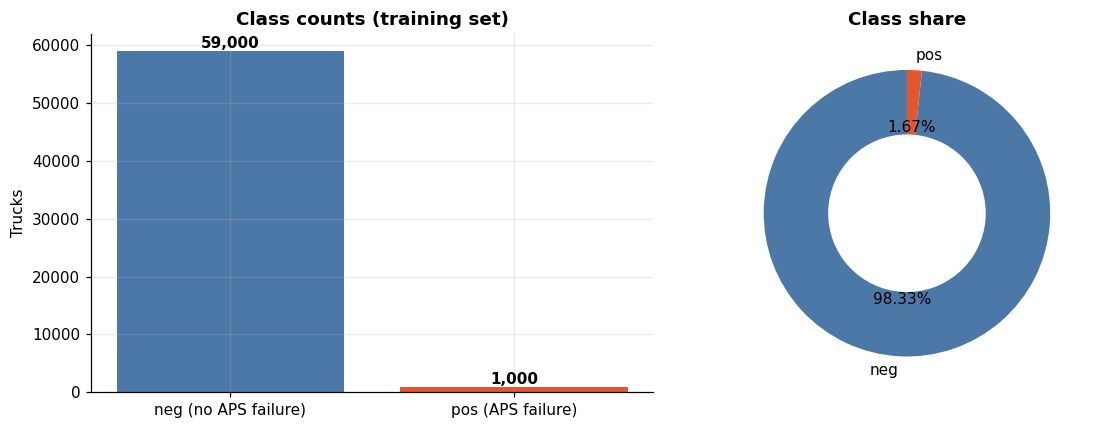

Imbalance ratio  neg:pos = 59.0 : 1


In [7]:
counts = train_df["class"].value_counts().sort_index()
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(["neg (no APS failure)", "pos (APS failure)"], counts.values, color=[COL["neg"], COL["pos"]])
for i, v in enumerate(counts.values): ax[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontweight="bold")
ax[0].set_title("Class counts (training set)"); ax[0].set_ylabel("Trucks")
ax[1].pie(counts.values, labels=["neg", "pos"], colors=[COL["neg"], COL["pos"]], autopct="%1.2f%%", startangle=90,
          wedgeprops=dict(width=0.45))
ax[1].set_title("Class share")
plt.tight_layout(); plt.show()
print(f"Imbalance ratio  neg:pos = {counts[0] / counts[1]:.1f} : 1")

### 3.2 Missing values
Missingness in industrial sensor data is rarely random. A sensor that is absent or failing may itself be a signal. We therefore inspect (a) how much is missing per feature, and (b) whether the missing rate **differs between failing and healthy trucks**.

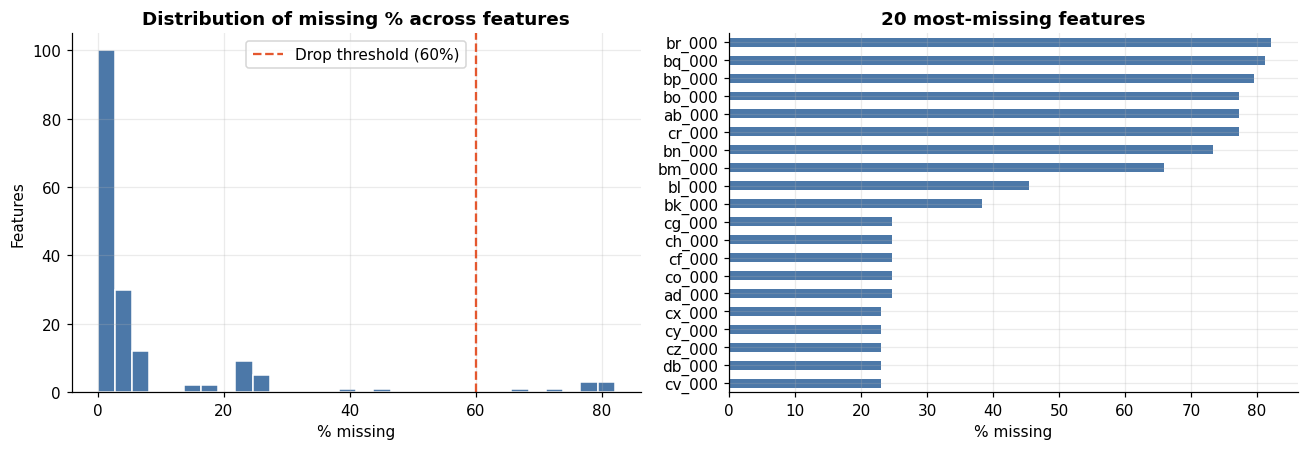

Features above the 60% threshold: 8

Features whose missingness differs most between classes:


,missing % (fail),missing % (healthy),gap (pp)
br_000,9.0000,83.3458,-74.3458
bq_000,8.7000,82.4322,-73.7322
bp_000,8.3000,80.7746,-72.4746
bo_000,7.8000,78.3983,-70.5983
bn_000,7.4000,74.4661,-67.0661
bm_000,7.1000,66.9119,-59.8119
ak_000,53.2000,6.5559,46.6441
ca_000,53.0000,6.4847,46.5153
di_000,52.4000,5.9017,46.4983
dj_000,52.4000,5.9034,46.4966


In [8]:
X_raw = train_df.drop(columns="class"); y_raw = train_df["class"]
miss = X_raw.isna().mean().sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].hist(miss * 100, bins=30, color=COL["neg"], edgecolor="white")
ax[0].axvline(MISSING_THRESHOLD * 100, color=COL["pos"], ls="--", label=f"Drop threshold ({MISSING_THRESHOLD:.0%})")
ax[0].set_title("Distribution of missing % across features"); ax[0].set_xlabel("% missing"); ax[0].set_ylabel("Features"); ax[0].legend()
miss.head(20).iloc[::-1].mul(100).plot.barh(ax=ax[1], color=COL["neg"])
ax[1].set_title("20 most-missing features"); ax[1].set_xlabel("% missing")
plt.tight_layout(); plt.show()
print(f"Features above the {MISSING_THRESHOLD:.0%} threshold: {(miss > MISSING_THRESHOLD).sum()}")

# Is missingness informative? compare missing rate in failing vs healthy trucks
gap = (X_raw[y_raw == 1].isna().mean() - X_raw[y_raw == 0].isna().mean()).sort_values(key=np.abs, ascending=False)
gap_tbl = pd.DataFrame({"missing % (fail)": X_raw[y_raw == 1].isna().mean()[gap.index[:10]] * 100,
                        "missing % (healthy)": X_raw[y_raw == 0].isna().mean()[gap.index[:10]] * 100})
gap_tbl["gap (pp)"] = gap_tbl.iloc[:, 0] - gap_tbl.iloc[:, 1]
print("\nFeatures whose missingness differs most between classes:")
display(gap_tbl)

**Interpretation.** Large gaps between the two columns indicate *informative missingness*. Tree models can exploit this after imputation only indirectly, which is why we later revisit missing-indicator features as a possible improvement (section 10).

### 3.3 Feature distributions and class separation
Sensor counters are heavily right-skewed, so we use a log scale. Features are ranked by the absolute point-biserial correlation with the target (median-imputed for this exploratory step only).

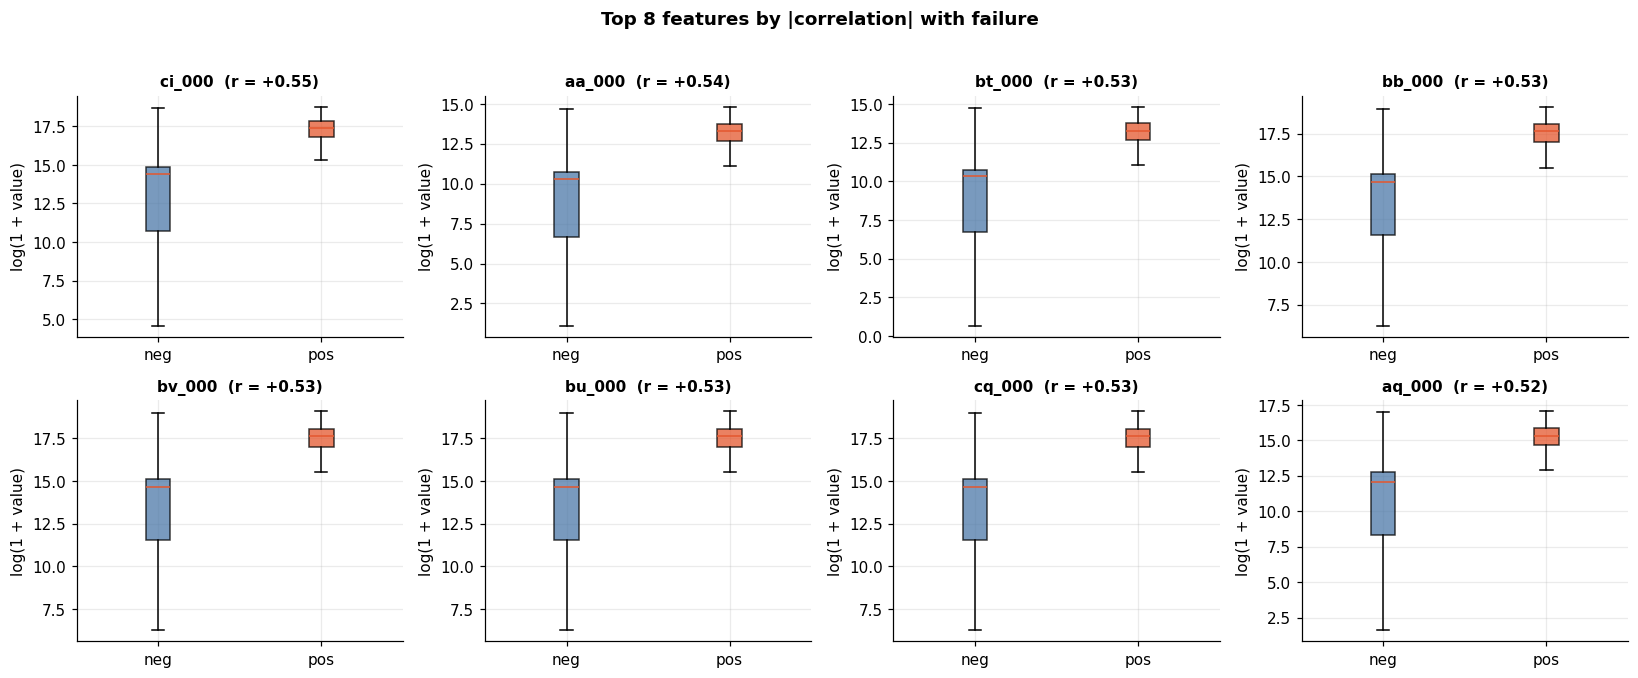

In [9]:
X_eda = X_raw.fillna(X_raw.median())
X_eda = X_eda.loc[:, X_eda.nunique() > 1]
corr_t = X_eda.apply(lambda s: np.corrcoef(s, y_raw)[0, 1]).dropna()
top_corr = corr_t.abs().sort_values(ascending=False).head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, f in zip(axes.ravel(), top_corr):
    data = [np.log1p(X_eda.loc[y_raw == 0, f].clip(lower=0)), np.log1p(X_eda.loc[y_raw == 1, f].clip(lower=0))]
    bp = ax.boxplot(data, labels=["neg", "pos"], patch_artist=True, showfliers=False)
    for patch, c in zip(bp["boxes"], [COL["neg"], COL["pos"]]): patch.set_facecolor(c); patch.set_alpha(.75)
    ax.set_title(f"{f}  (r = {corr_t[f]:+.2f})", fontsize=10); ax.set_ylabel("log(1 + value)")
plt.suptitle("Top 8 features by |correlation| with failure", fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

### 3.4 Multicollinearity
Many APS features are histogram bins or counters of the same physical signal, so they are strongly correlated. This does not hurt tree ensembles, but it **matters for interpretation**: SHAP splits credit among correlated features (see the limitations in section 10).

Feature pairs with |r| > 0.95: 55 of 14,196  (0.4%)


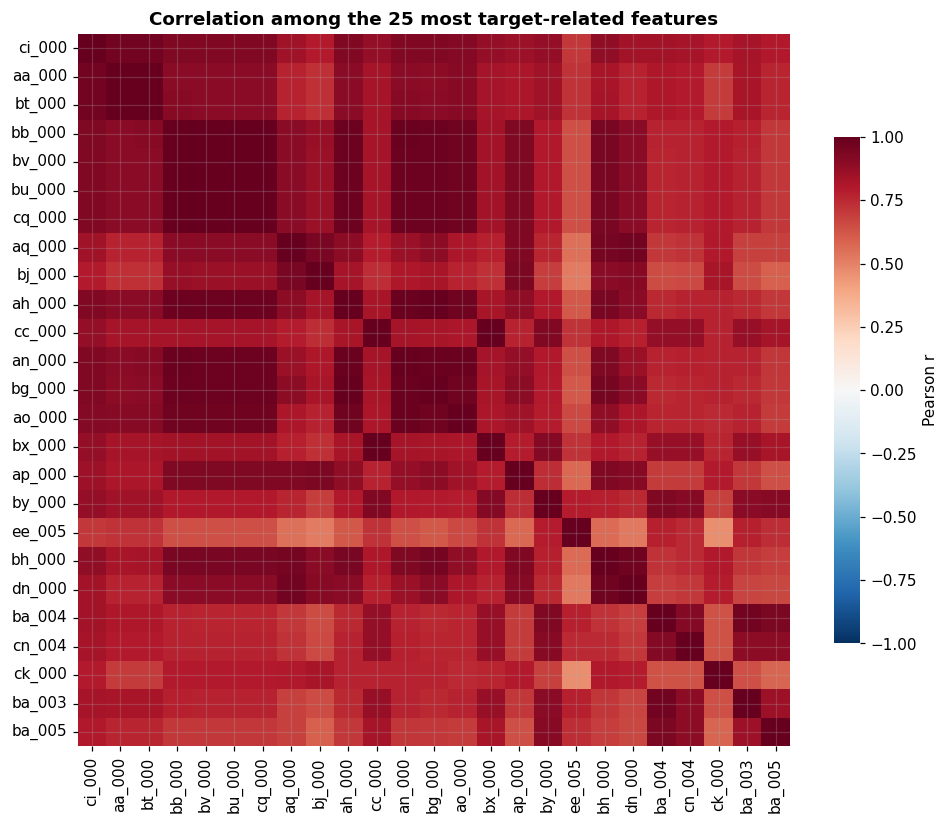

In [10]:
corr = X_eda.corr()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).abs()
pairs = upper.stack()
print(f"Feature pairs with |r| > 0.95: {(pairs > 0.95).sum():,} of {len(pairs):,}  ({(pairs > 0.95).mean():.1%})")

top25 = corr_t.abs().sort_values(ascending=False).head(25).index
plt.figure(figsize=(9, 7.5))
sns.heatmap(X_eda[top25].corr(), cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={"shrink": .7, "label": "Pearson r"}, xticklabels=True, yticklabels=True)
plt.title("Correlation among the 25 most target-related features"); plt.tight_layout(); plt.show()

## 4. Preparing the data without leakage
**Rule: anything learned from data (medians, dropped columns) is learned on the training split only**, then applied unchanged to validation and test. Doing it in the other order leaks information and inflates results.

Steps:
1. Stratified **train / validation** split of the official training file (the validation set is used for model selection, threshold tuning and SHAP-based feature ranking).
2. The official **test file is kept untouched** as the final hold-out.
3. Drop features with more than the threshold missing, and constant features.
4. Median-impute the rest (robust to the heavy skew).

In [11]:
X_all, y_all = train_df.drop(columns="class"), train_df["class"]
X_te, y_te   = test_df.drop(columns="class"),  test_df["class"]

X_tr, X_val, y_tr, y_val = train_test_split(X_all, y_all, test_size=VAL_SIZE, stratify=y_all, random_state=RANDOM_STATE)

miss_tr   = X_tr.isna().mean()
drop_miss = set(miss_tr[miss_tr > MISSING_THRESHOLD].index)
drop_const = set(X_tr.columns[X_tr.nunique(dropna=True) <= 1])
keep = [c for c in X_tr.columns if c not in drop_miss | drop_const]

imputer = SimpleImputer(strategy="median").fit(X_tr[keep])
def prep(X): return pd.DataFrame(imputer.transform(X[keep]), columns=keep, index=X.index)
X_tr_p, X_val_p, X_te_p = prep(X_tr), prep(X_val), prep(X_te)

print(f"Dropped for missingness: {len(drop_miss)} | constant: {len(drop_const)} | kept: {len(keep)}")
print(pd.DataFrame({"rows": [len(X_tr_p), len(X_val_p), len(X_te_p)],
                    "failures": [y_tr.sum(), y_val.sum(), y_te.sum()],
                    "failure %": [y_tr.mean() * 100, y_val.mean() * 100, y_te.mean() * 100]},
                   index=["train", "validation", "test (hold-out)"]).round(3))

Dropped for missingness: 8 | constant: 1 | kept: 161
                  rows  failures  failure %
train            48000       800     1.6670
validation       12000       200     1.6670
test (hold-out)  16000       375     2.3440


## 5. Training the models
Four candidates spanning linear, bagged-tree and boosted-tree families, plus two ways of handling imbalance:

| Model | Imbalance strategy | Why include it |
|---|---|---|
| Logistic Regression | `class_weight="balanced"` + quantile-normal scaling | Interpretable baseline |
| Random Forest | `class_weight="balanced_subsample"` | Strong, low-tuning non-linear baseline |
| XGBoost | `scale_pos_weight = neg / pos` | Cost-sensitive boosting |
| XGBoost + SMOTE | Synthetic minority oversampling **inside** the pipeline (never touches validation/test) | Tests resampling against re-weighting |

In [12]:
neg, pos = int((y_tr == 0).sum()), int((y_tr == 1).sum())
spw = neg / pos

XGB_PARAMS = dict(n_estimators=400, learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8,
                  reg_lambda=1.0, eval_metric="aucpr", tree_method="hist", random_state=RANDOM_STATE, n_jobs=-1)

models = {
    "Logistic Regression": Pipeline([("scale", QuantileTransformer(n_quantiles=200, output_distribution="normal", random_state=RANDOM_STATE)),
                                     ("clf", LogisticRegression(class_weight="balanced", C=0.1, max_iter=2000))]),
    "Random Forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=2, class_weight="balanced_subsample",
                                            n_jobs=-1, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(**XGB_PARAMS, scale_pos_weight=spw),
    "XGBoost + SMOTE": ImbPipeline([("smote", SMOTE(sampling_strategy=0.25, random_state=RANDOM_STATE)),
                                    ("clf", XGBClassifier(**XGB_PARAMS))]),
}

fit_time = {}
for name, m in models.items():
    t0 = time.time(); m.fit(X_tr_p, y_tr); fit_time[name] = time.time() - t0
    print(f"{name:<22} fitted in {fit_time[name]:6.1f}s")

val_proba  = {n: m.predict_proba(X_val_p)[:, 1] for n, m in models.items()}
test_proba = {n: m.predict_proba(X_te_p)[:, 1]  for n, m in models.items()}

Logistic Regression    fitted in   11.3s
Random Forest          fitted in   50.7s
XGBoost                fitted in   10.1s
XGBoost + SMOTE        fitted in   11.6s


### 5.1 Cross-validation (stability check)
A single split can be lucky. Stratified 3-fold CV on the training portion reports mean ± standard deviation of ROC-AUC and PR-AUC, so we can judge whether differences between models are real.

In [13]:
if RUN_CV:
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    rows = []
    for name, m in models.items():
        r = cross_validate(clone(m), X_tr_p, y_tr, cv=cv, scoring={"auc": "roc_auc", "ap": "average_precision"}, n_jobs=1)
        rows.append({"Model": name, "ROC-AUC": r["test_auc"].mean(), "ROC-AUC sd": r["test_auc"].std(),
                     "PR-AUC": r["test_ap"].mean(), "PR-AUC sd": r["test_ap"].std()})
    cv_tbl = pd.DataFrame(rows).set_index("Model")
    display(cv_tbl.style.format("{:.4f}").highlight_max(subset=["ROC-AUC", "PR-AUC"], color="#cfe8e4"))
else:
    print("RUN_CV = False, skipping cross-validation.")

,ROC-AUC,ROC-AUC sd,PR-AUC,PR-AUC sd
Model,,,,
Logistic Regression,0.9842,0.0019,0.7465,0.0052
Random Forest,0.9854,0.0038,0.8164,0.0253
XGBoost,0.9869,0.0033,0.8742,0.0182
XGBoost + SMOTE,0.9879,0.0030,0.8635,0.0162


## 6. Evaluating the models
### 6.1 Ranking quality on the validation set
ROC-AUC can look excellent under heavy imbalance because true negatives dominate. **PR-AUC** focuses on the minority class and is the more honest ranking metric here.

In [14]:
def cost_of(y, pred):
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return COST_FP * fp + COST_FN * fn

def evaluate(name, y, proba, thr=0.5):
    pred = (proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {"Model": name, "Threshold": thr, "Accuracy": accuracy_score(y, pred),
            "Precision": precision_score(y, pred, zero_division=0), "Recall": recall_score(y, pred),
            "F1": f1_score(y, pred), "ROC-AUC": roc_auc_score(y, proba), "PR-AUC": average_precision_score(y, proba),
            "FP": fp, "FN": fn, "Cost": COST_FP * fp + COST_FN * fn}

val_default = pd.DataFrame([evaluate(n, y_val, p) for n, p in val_proba.items()]).set_index("Model")
display(val_default.style.format({c: "{:.4f}" for c in ["Threshold", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]} | {"Cost": "{:,.0f}"})
        .highlight_max(subset=["Recall", "F1", "ROC-AUC", "PR-AUC"], color="#cfe8e4").highlight_min(subset=["Cost"], color="#cfe8e4"))

,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,FP,FN,Cost
Model,,,,,,,,,,
Logistic Regression,0.5000,0.9578,0.2789,0.9650,0.4327,0.9914,0.7523,499,7,"8,490"
Random Forest,0.5000,0.9928,0.8314,0.7150,0.7688,0.9931,0.8584,29,57,"28,790"
XGBoost,0.5000,0.9921,0.7059,0.9000,0.7912,0.9944,0.9013,75,20,"10,750"
XGBoost + SMOTE,0.5000,0.9936,0.8060,0.8100,0.8080,0.9948,0.8869,39,38,"19,390"


In [15]:
colors = {"Logistic Regression": COL["grey"], "Random Forest": COL["gold"], "XGBoost": COL["neg"], "XGBoost + SMOTE": COL["pos"]}
fig = make_subplots(rows=1, cols=2, subplot_titles=("ROC curve (validation)", "Precision-Recall curve (validation)"))
for n, p in val_proba.items():
    fpr, tpr, _ = roc_curve(y_val, p); pr, rc, _ = precision_recall_curve(y_val, p)
    fig.add_trace(go.Scatter(x=fpr, y=tpr, name=f"{n} (AUC {roc_auc_score(y_val, p):.3f})", line=dict(color=colors[n]), legendgroup=n), row=1, col=1)
    fig.add_trace(go.Scatter(x=rc, y=pr, name=f"{n} (AP {average_precision_score(y_val, p):.3f})", line=dict(color=colors[n]), legendgroup=n, showlegend=False), row=1, col=2)
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], line=dict(color="lightgrey", dash="dash"), showlegend=False), row=1, col=1)
fig.add_hline(y=y_val.mean(), line=dict(color="lightgrey", dash="dash"), row=1, col=2)
fig.update_xaxes(title_text="False positive rate", row=1, col=1); fig.update_yaxes(title_text="True positive rate", row=1, col=1)
fig.update_xaxes(title_text="Recall", row=1, col=2); fig.update_yaxes(title_text="Precision", row=1, col=2)
fig.update_layout(height=430, template="plotly_white", legend=dict(orientation="h", y=-0.2))
fig.show()

### 6.2 Dual-threshold optimisation
The default 0.5 cut-off is arbitrary. Under a 50:1 cost asymmetry the best operating point is far lower. We sweep thresholds **on the validation set only** and pick two operating points:

* **F1-optimal**: balanced precision and recall. Suitable when workshop capacity is limited.
* **Cost-optimal**: minimises `10·FP + 500·FN`. This is the *business* threshold.

(For a well-calibrated model the theoretical cost-optimal threshold is `C_FP / (C_FP + C_FN) ≈ 0.02`. Class weighting inflates the probabilities, so the empirical optimum will be higher; that is expected.)

In [16]:
GRID = np.unique(np.r_[np.arange(0.001, 0.05, 0.001), np.arange(0.05, 1.0, 0.01)]).round(3)

def sweep(y, p):
    y = np.asarray(y); rows = []
    for t in GRID:
        pred = p >= t
        tp = (pred & (y == 1)).sum(); fp = (pred & (y == 0)).sum(); fn = ((~pred) & (y == 1)).sum()
        prec = tp / (tp + fp) if tp + fp else 0.0; rec = tp / (tp + fn) if tp + fn else 0.0
        f1 = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
        rows.append((t, prec, rec, f1, fp, fn, COST_FP * fp + COST_FN * fn))
    return pd.DataFrame(rows, columns=["threshold", "precision", "recall", "f1", "FP", "FN", "cost"])

def best_thresholds(y, p):
    s = sweep(y, p)
    thr_cost = s.loc[s.cost == s.cost.min(), "threshold"].median()   # middle of the plateau = more stable than argmin
    thr_f1   = s.loc[s.f1 == s.f1.max(), "threshold"].median()
    return thr_f1, thr_cost, s

val_thr = {n: best_thresholds(y_val, p) for n, p in val_proba.items()}
tbl = pd.DataFrame({n: {"F1-optimal thr": v[0], "Cost-optimal thr": v[1], "Min val cost": v[2].cost.min(),
                        "Val cost @0.5": val_default.loc[n, "Cost"]} for n, v in val_thr.items()}).T
display(tbl.style.format({"F1-optimal thr": "{:.3f}", "Cost-optimal thr": "{:.3f}", "Min val cost": "{:,.0f}", "Val cost @0.5": "{:,.0f}"}))

tree_models = [n for n in models if n != "Logistic Regression"]
final_name = min(tree_models, key=lambda n: val_thr[n][2].cost.min())
final_model = models[final_name]
thr_f1, thr_cost, sw = val_thr[final_name]
print(f"\nSelected model (lowest validation cost among tree ensembles, so SHAP TreeExplainer applies): {final_name}")
print(f"F1-optimal threshold = {thr_f1:.3f} | Cost-optimal threshold = {thr_cost:.3f}")

,F1-optimal thr,Cost-optimal thr,Min val cost,Val cost @0.5
Logistic Regression,0.980,0.630,"7,460","8,490"
Random Forest,0.420,0.070,"6,410","28,790"
XGBoost,0.820,0.140,"5,830","10,750"
XGBoost + SMOTE,0.650,0.019,"5,970","19,390"



Selected model (lowest validation cost among tree ensembles, so SHAP TreeExplainer applies): XGBoost
F1-optimal threshold = 0.820 | Cost-optimal threshold = 0.140


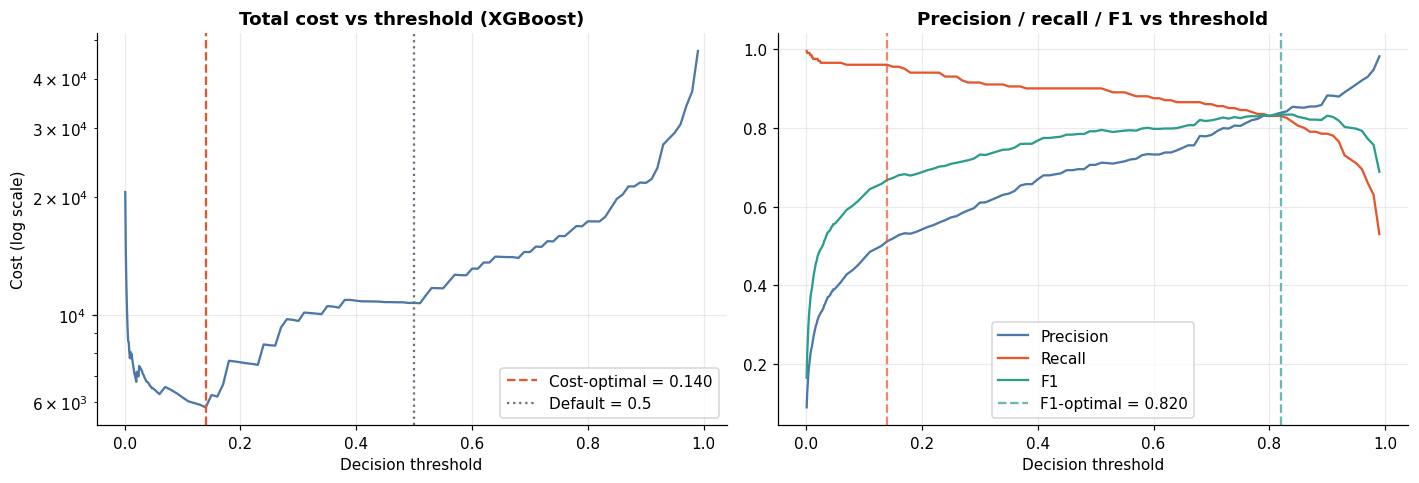

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(sw.threshold, sw.cost, color=COL["neg"]); ax[0].set_yscale("log")
ax[0].axvline(thr_cost, color=COL["pos"], ls="--", label=f"Cost-optimal = {thr_cost:.3f}")
ax[0].axvline(0.5, color=COL["grey"], ls=":", label="Default = 0.5")
ax[0].set_title(f"Total cost vs threshold ({final_name})"); ax[0].set_xlabel("Decision threshold"); ax[0].set_ylabel("Cost (log scale)"); ax[0].legend()
for c, lab, colr in [("precision", "Precision", COL["neg"]), ("recall", "Recall", COL["pos"]), ("f1", "F1", COL["teal"])]:
    ax[1].plot(sw.threshold, sw[c], label=lab, color=colr)
ax[1].axvline(thr_f1, color=COL["teal"], ls="--", alpha=.7, label=f"F1-optimal = {thr_f1:.3f}")
ax[1].axvline(thr_cost, color=COL["pos"], ls="--", alpha=.7)
ax[1].set_title("Precision / recall / F1 vs threshold"); ax[1].set_xlabel("Decision threshold"); ax[1].legend()
plt.tight_layout(); plt.show()

### 6.3 Final hold-out test results
Thresholds were fixed on the validation set; the test set is scored **once**. First a fair comparison of all models at *their own* cost-optimal threshold, then the three operating points for the selected model.

**All models on the hold-out test set at their validation-selected cost-optimal threshold**

,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,FP,FN,Cost
Model,,,,,,,,,,
Logistic Regression,0.6300,0.9706,0.4395,0.9307,0.5971,0.9890,0.8119,445,26,"17,450"
Random Forest,0.0700,0.9726,0.4598,0.9600,0.6218,0.9930,0.8836,423,15,"11,730"
XGBoost,0.1400,0.9849,0.6196,0.9253,0.7422,0.9946,0.9252,213,28,"16,130"
XGBoost + SMOTE,0.0190,0.9729,0.4624,0.9520,0.6225,0.9947,0.9196,415,18,"13,150"


**XGBoost: three operating points on the test set**

,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,FP,FN,Cost
Model,,,,,,,,,,
Default (0.50),0.5000,0.9914,0.7917,0.8613,0.8250,0.9946,0.9252,85,52,"26,850"
F1-optimal,0.8200,0.9937,0.9102,0.8107,0.8575,0.9946,0.9252,30,71,"35,800"
Cost-optimal,0.1400,0.9849,0.6196,0.9253,0.7422,0.9946,0.9252,213,28,"16,130"


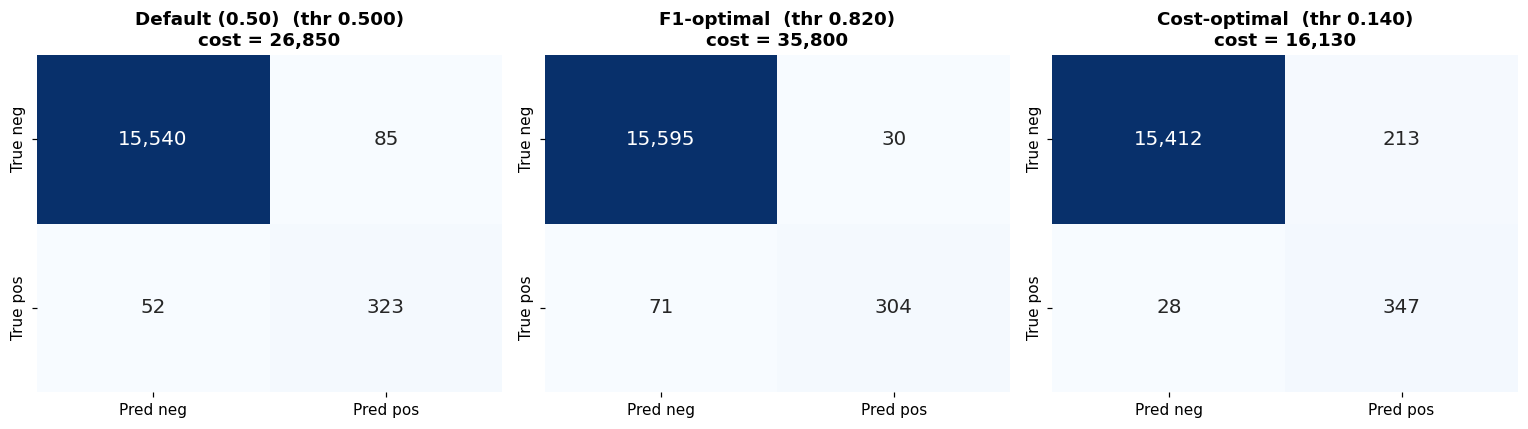

In [18]:
rows = [evaluate(n, y_te, test_proba[n], val_thr[n][1]) for n in models]
test_all = pd.DataFrame(rows).set_index("Model")
display(Markdown("**All models on the hold-out test set at their validation-selected cost-optimal threshold**"))
display(test_all.style.format({c: "{:.4f}" for c in ["Threshold", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]} | {"Cost": "{:,.0f}"})
        .highlight_min(subset=["Cost"], color="#cfe8e4").highlight_max(subset=["Recall", "PR-AUC"], color="#cfe8e4"))

op_points = {"Default (0.50)": 0.5, "F1-optimal": thr_f1, "Cost-optimal": thr_cost}
ops = pd.DataFrame([evaluate(k, y_te, test_proba[final_name], t) for k, t in op_points.items()]).set_index("Model")
display(Markdown(f"**{final_name}: three operating points on the test set**"))
display(ops.style.format({c: "{:.4f}" for c in ["Threshold", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]} | {"Cost": "{:,.0f}"})
        .highlight_min(subset=["Cost"], color="#cfe8e4"))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (k, t) in zip(axes, op_points.items()):
    cm = confusion_matrix(y_te, (test_proba[final_name] >= t).astype(int), labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax, xticklabels=["Pred neg", "Pred pos"], yticklabels=["True neg", "True pos"], annot_kws={"size": 13})
    ax.set_title(f"{k}  (thr {t:.3f})\ncost = {cost_of(y_te, (test_proba[final_name] >= t).astype(int)):,}"); ax.grid(False)
plt.tight_layout(); plt.show()

### 6.4 Uncertainty: bootstrap confidence interval for the test cost
A single cost figure hides sampling noise, and with only a few hundred failures in the test set that noise is material. We resample the test set 500 times at the fixed cost-optimal threshold.

Test cost = 16,130   95% bootstrap CI = [10,924, 21,362]


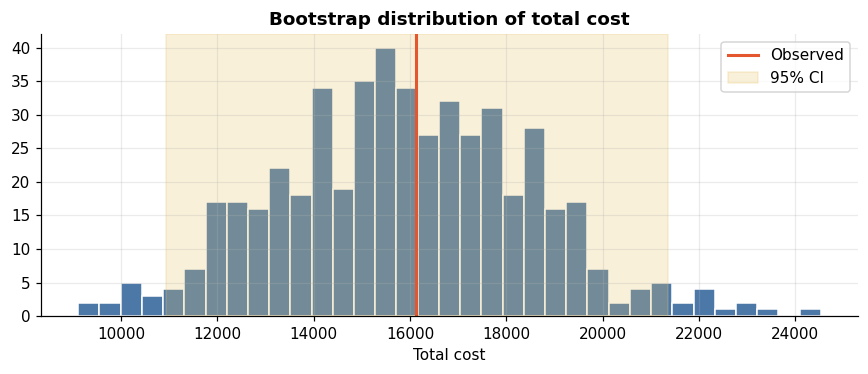

In [19]:
y_arr = y_te.values; pred_arr = (test_proba[final_name] >= thr_cost).astype(int)
boot = []
for _ in range(500):
    idx = rng.integers(0, len(y_arr), len(y_arr))
    boot.append(cost_of(y_arr[idx], pred_arr[idx]))
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"Test cost = {cost_of(y_arr, pred_arr):,}   95% bootstrap CI = [{lo:,.0f}, {hi:,.0f}]")
plt.figure(figsize=(8, 3.5)); plt.hist(boot, bins=35, color=COL["neg"], edgecolor="white")
plt.axvline(cost_of(y_arr, pred_arr), color=COL["pos"], lw=2, label="Observed"); plt.axvspan(lo, hi, color=COL["gold"], alpha=.25, label="95% CI")
plt.title("Bootstrap distribution of total cost"); plt.xlabel("Total cost"); plt.legend(); plt.tight_layout(); plt.show()

## 7. What the results mean in practice
Cost is only meaningful relative to alternatives. We compare the model against the two naive policies a fleet operator might otherwise follow.

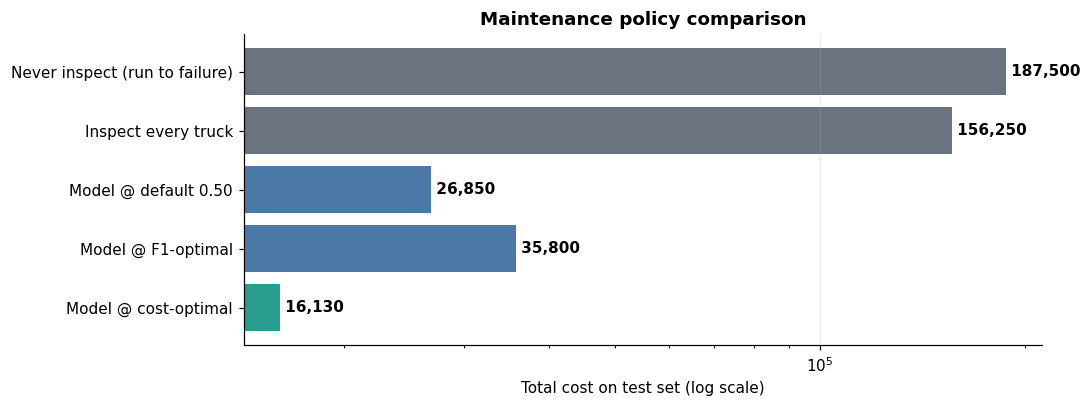

Saving vs best naive policy: 140,120 cost units (89.7%).
Failures caught: 347 of 375 (92.5%) at the price of 213 extra workshop checks.


In [20]:
n_pos, n_neg = int(y_te.sum()), int((y_te == 0).sum())
policies = pd.Series({
    "Never inspect (run to failure)": COST_FN * n_pos,
    "Inspect every truck": COST_FP * n_neg,
    f"Model @ default 0.50": ops.loc["Default (0.50)", "Cost"],
    f"Model @ F1-optimal": ops.loc["F1-optimal", "Cost"],
    f"Model @ cost-optimal": ops.loc["Cost-optimal", "Cost"],
})
fig, ax = plt.subplots(figsize=(10, 3.8))
bars = ax.barh(policies.index[::-1], policies.values[::-1], color=[COL["teal"], COL["neg"], COL["neg"], COL["grey"], COL["grey"]])
for b, v in zip(bars, policies.values[::-1]): ax.text(v, b.get_y() + b.get_height() / 2, f" {v:,.0f}", va="center", fontweight="bold")
ax.set_xscale("log"); ax.set_xlabel("Total cost on test set (log scale)"); ax.set_title("Maintenance policy comparison"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

best_naive = min(policies.iloc[:2]); best_model = policies.iloc[-1]
print(f"Saving vs best naive policy: {best_naive - best_model:,.0f} cost units ({(1 - best_model / best_naive):.1%}).")
print(f"Failures caught: {n_pos - ops.loc['Cost-optimal', 'FN']} of {n_pos} ({ops.loc['Cost-optimal', 'Recall']:.1%}) "
      f"at the price of {ops.loc['Cost-optimal', 'FP']:,} extra workshop checks.")

## 8. Understanding the model with SHAP
A maintenance engineer will not trust (or act on) a black-box alert. **SHAP (SHapley Additive exPlanations)** decomposes each prediction into a per-feature contribution grounded in cooperative game theory.

**How to read SHAP values**

* For a row *x*, the model output equals `base value + Σ SHAP(feature_i)`. This is *additivity*, and we verify it numerically below.
* For XGBoost, SHAP values are in **log-odds** space. A positive value pushes the prediction towards *failure*, a negative value towards *healthy*.
* **Global** importance = mean |SHAP| over many rows. **Local** explanation = the SHAP values of one truck.
* SHAP is a statement about *what the model uses*, not about physical causation.

Sections: 8.1 compute and verify, 8.2 global importance, 8.3 direction and shape of effects, 8.4 sensor-family aggregation, 8.5 interactions, 8.6 individual predictions, 8.7 comparison with other importance methods, 8.8 robustness, 8.9 SHAP-guided feature reduction.

### 8.1 Compute SHAP values and verify additivity

In [21]:
def get_booster(m): return m.named_steps["clf"] if hasattr(m, "named_steps") else m
is_xgb = isinstance(get_booster(final_model), XGBClassifier)

def compute_shap(model, X, cap=SHAP_MAX_ROWS):
    if len(X) > cap: X = X.sample(cap, random_state=RANDOM_STATE)
    expl = shap.TreeExplainer(get_booster(model))
    sv = expl(X, check_additivity=False)
    if sv.values.ndim == 3: sv = sv[..., 1]          # random forest returns one slice per class
    return expl, sv, X

t0 = time.time()
explainer, sv, X_s = compute_shap(final_model, X_te_p)
print(f"SHAP computed for {len(X_s):,} test rows x {X_s.shape[1]} features in {time.time() - t0:.0f}s")

y_s = y_te.loc[X_s.index].values
p_s = pd.Series(test_proba[final_name], index=X_te_p.index).loc[X_s.index].values
pred_s = (p_s >= thr_cost).astype(int)
base = float(np.ravel(sv.base_values)[0])

if is_xgb:
    margin = get_booster(final_model).predict(X_s, output_margin=True)
    err = np.abs(sv.base_values + sv.values.sum(1) - margin).max()
    print(f"Additivity check: max |base + sum(SHAP) - model log-odds| = {err:.2e}  ({'OK' if err < 1e-3 else 'CHECK'})")
print(f"Base value (average model output, log-odds) = {base:.3f}")

imp = pd.Series(np.abs(sv.values).mean(0), index=X_s.columns).sort_values(ascending=False)

SHAP computed for 16,000 test rows x 161 features in 6s
Additivity check: max |base + sum(SHAP) - model log-odds| = 1.14e-05  (OK)
Base value (average model output, log-odds) = 1.059


### 8.2 Global importance
Two complementary views: the **bar plot** (how much a feature matters on average) and the **beeswarm** (how it matters). In the beeswarm each dot is one truck, the x-position is the SHAP value, and colour is the feature value (red = high, blue = low).

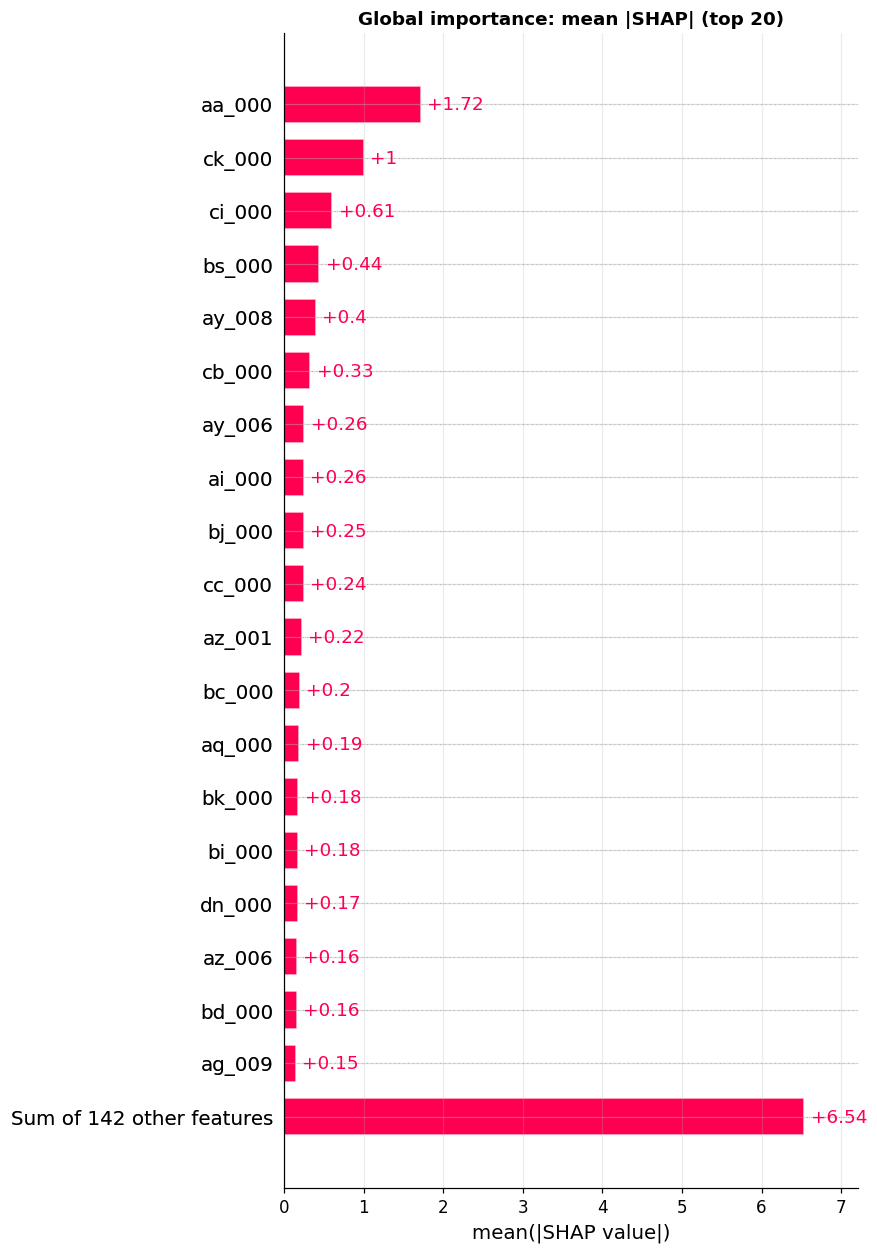

In [22]:
plt.figure(); shap.plots.bar(sv, max_display=TOP_N, show=False)
plt.title(f"Global importance: mean |SHAP| (top {TOP_N})"); plt.tight_layout(); plt.show()

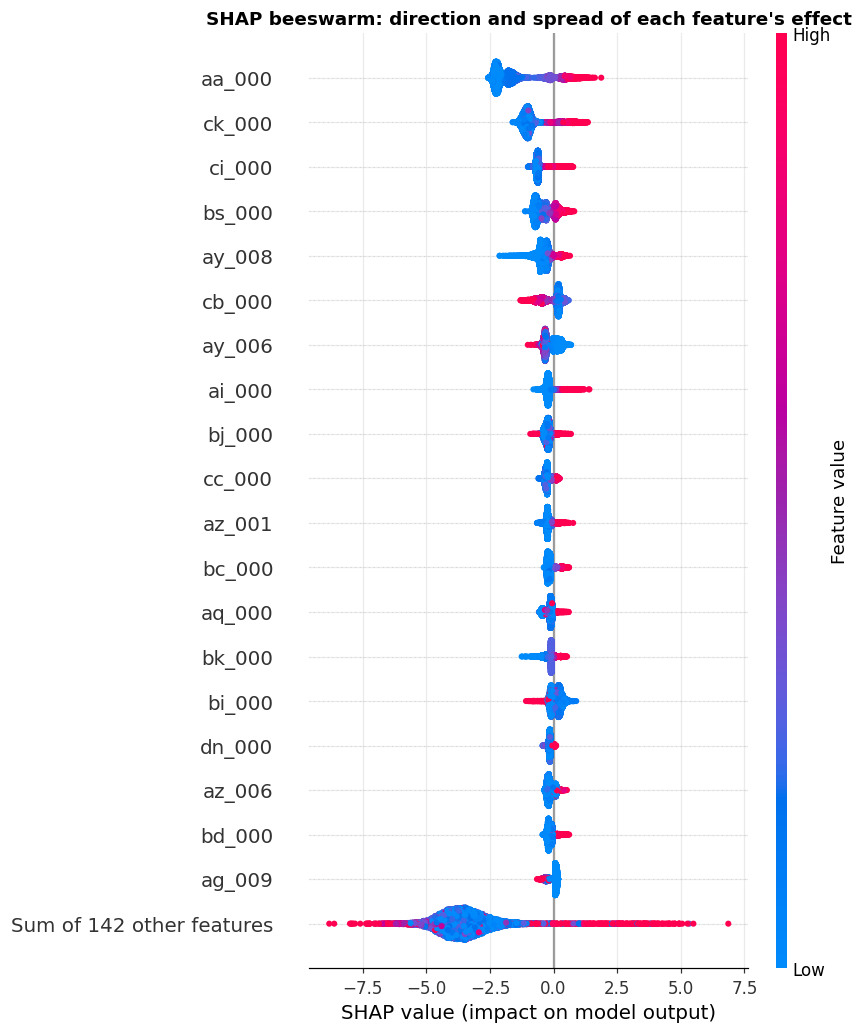

In [23]:
plt.figure(); shap.plots.beeswarm(sv, max_display=TOP_N, show=False)
plt.title("SHAP beeswarm: direction and spread of each feature's effect"); plt.tight_layout(); plt.show()

**Reading the beeswarm.** For a top feature, if the red dots (high values) sit to the *right* of zero, higher sensor readings raise failure risk. A long tail of dots far to the right means a small number of trucks receive a very strong signal (typical for rare-event detection). Mixed colours on both sides indicate that the effect depends on interactions with other features (see 8.5).

**How concentrated is the signal?** If a handful of features carry most of the importance, the model could be simplified; if importance is spread out, the failure signature is distributed across many sensors.

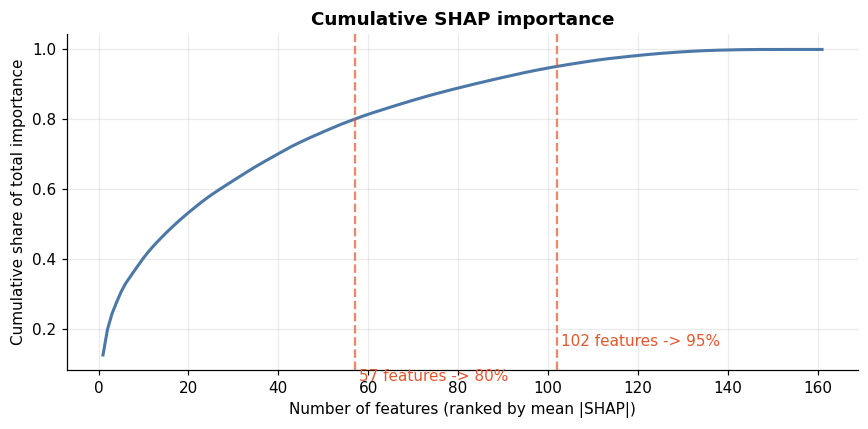

In [24]:
cum = imp.cumsum() / imp.sum()
n80, n95 = int((cum < 0.80).sum() + 1), int((cum < 0.95).sum() + 1)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cum) + 1), cum.values, color=COL["neg"], lw=2)
for k, lab in [(n80, "80%"), (n95, "95%")]:
    ax.axvline(k, color=COL["pos"], ls="--", alpha=.7); ax.text(k + 1, 0.05 + (0.1 if lab == "95%" else 0), f"{k} features -> {lab}", color=COL["pos"])
ax.set_xlabel("Number of features (ranked by mean |SHAP|)"); ax.set_ylabel("Cumulative share of total importance")
ax.set_title("Cumulative SHAP importance"); plt.tight_layout(); plt.show()

### 8.3 Direction and shape of effects (dependence plots)
A dependence plot shows a feature's SHAP value against its raw value. Non-linear shapes, thresholds and plateaus are visible here and would be invisible in a linear coefficient. The colour axis is automatically the feature that interacts most with the one plotted.

<Figure size 770x462 with 0 Axes>

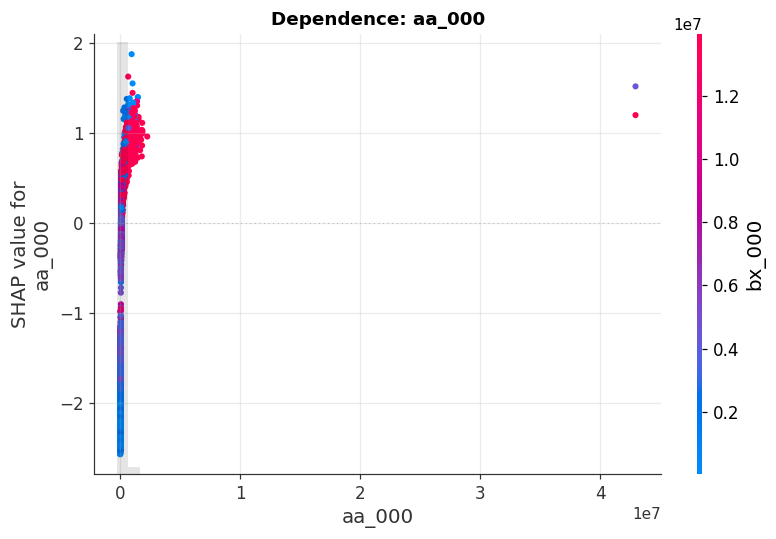

<Figure size 770x462 with 0 Axes>

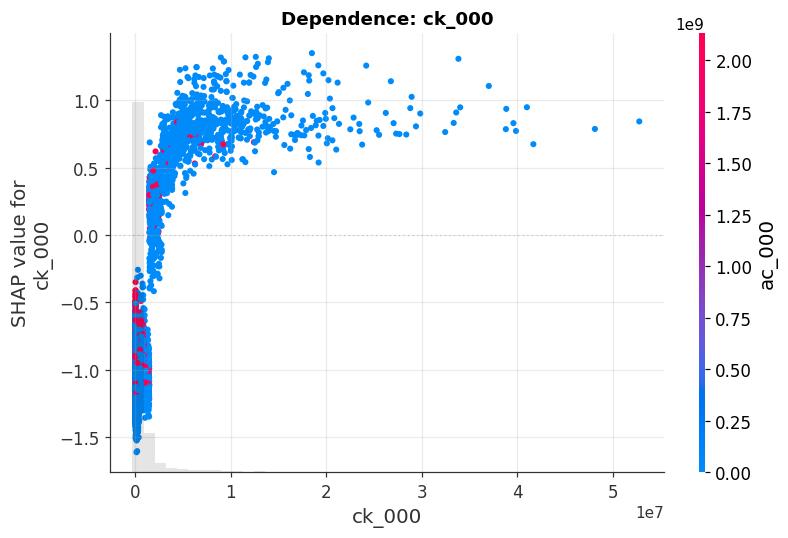

<Figure size 770x462 with 0 Axes>

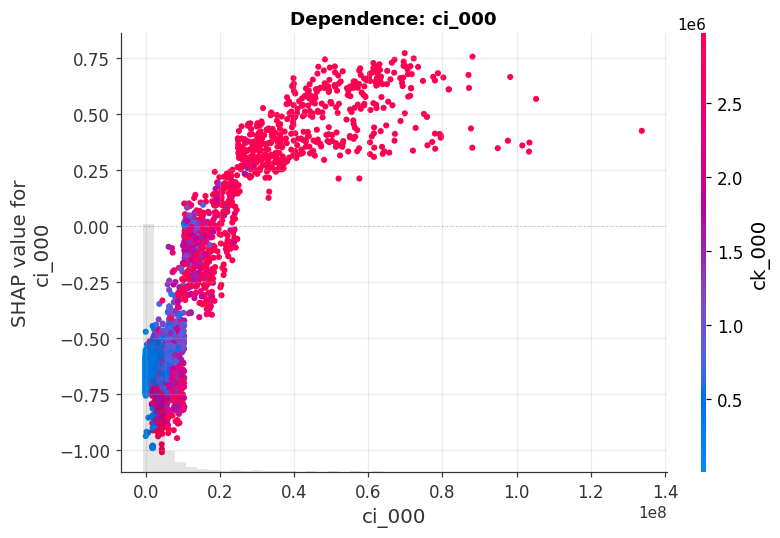

<Figure size 770x462 with 0 Axes>

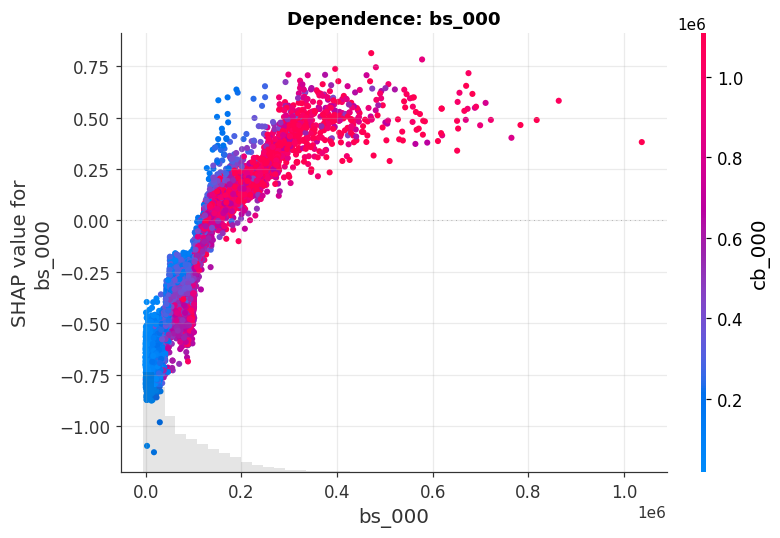

In [25]:
for f in imp.index[:4]:
    plt.figure(figsize=(7, 4.2))
    try:    shap.plots.scatter(sv[:, f], color=sv, show=False)
    except Exception: shap.plots.scatter(sv[:, f], show=False)
    plt.title(f"Dependence: {f}"); plt.tight_layout(); plt.show()

### 8.4 Failing versus healthy trucks
Average importance over all trucks is dominated by the 98% healthy majority. Here we compare mean |SHAP| **among true failures only** with the overall figure. Features that rank higher for failures are the ones that actually *discriminate* failure cases.

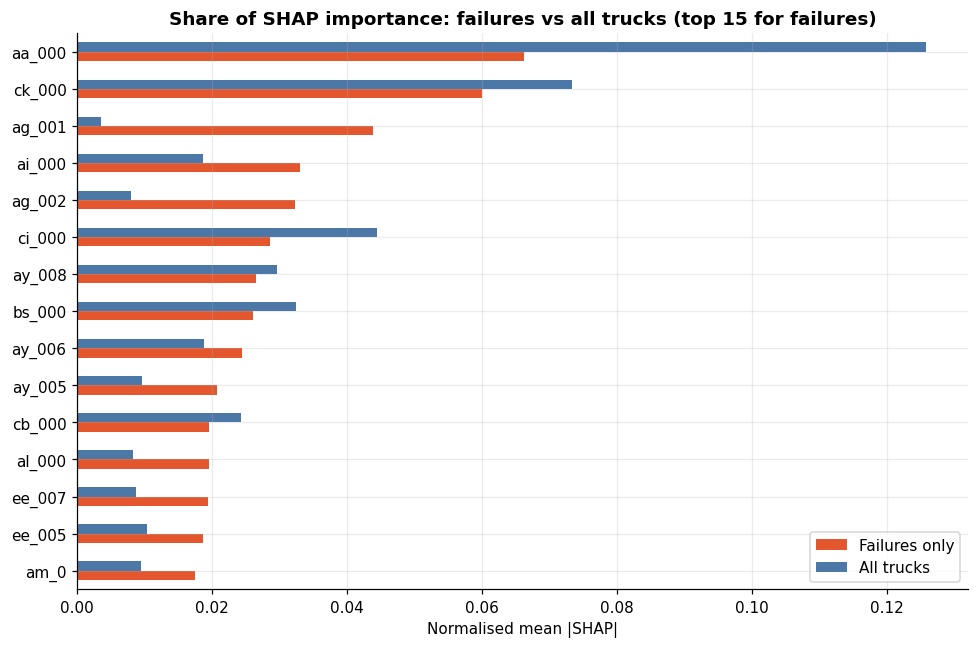

In [26]:
imp_fail = pd.Series(np.abs(sv.values[y_s == 1]).mean(0), index=X_s.columns)
imp_all_n = imp / imp.sum(); imp_fail_n = imp_fail / imp_fail.sum()
top = imp_fail_n.sort_values(ascending=False).head(15).index
cmp = pd.DataFrame({"Failures only": imp_fail_n[top], "All trucks": imp_all_n[top]})
cmp.iloc[::-1].plot.barh(figsize=(9, 6), color=[COL["pos"], COL["neg"]])
plt.title("Share of SHAP importance: failures vs all trucks (top 15 for failures)"); plt.xlabel("Normalised mean |SHAP|"); plt.tight_layout(); plt.show()

### 8.5 Sensor-family aggregation
APS feature names are anonymised as `<prefix>_<index>`. Features sharing a prefix belong to one sensor family (the `ag`, `ay`, `az`, `ba`, `cn`, `cs`, `ee` families are 10-bin histograms of a single measurement). Summing SHAP over a family answers "which *subsystem* drives the alert?", which is what a workshop can act on, and it also side-steps the credit-splitting problem among correlated bins.

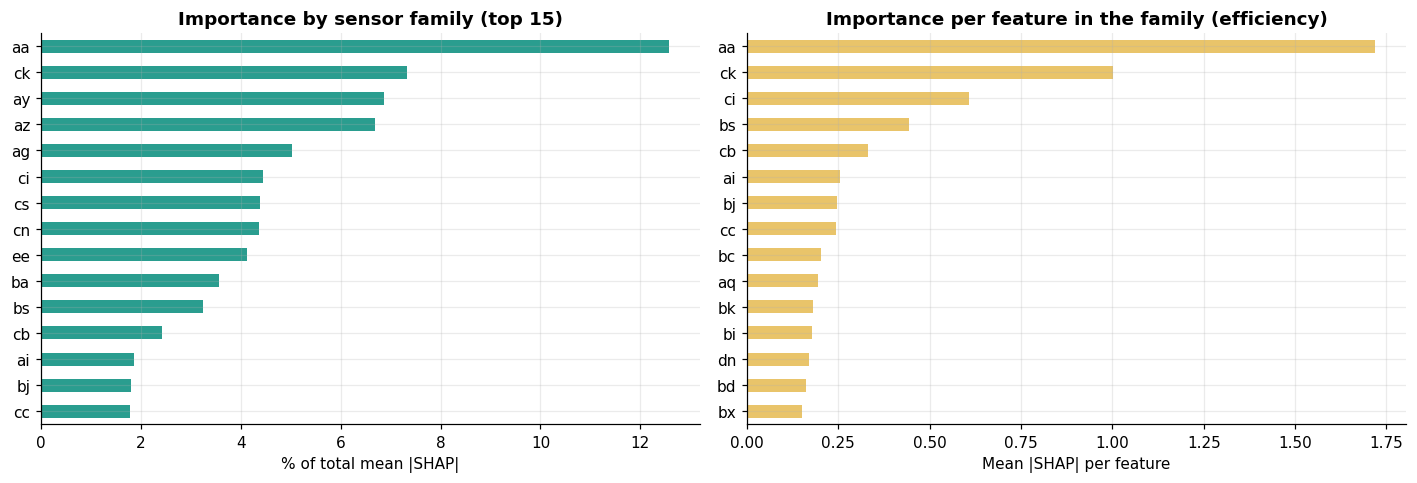

In [27]:
fam = imp.groupby(lambda c: c.split("_")[0]).sum().sort_values(ascending=False)
fam_n = (fam / fam.sum() * 100)
n_in_fam = pd.Series(X_s.columns).groupby(lambda i: X_s.columns[i].split("_")[0]).size()

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
fam_n.head(15).iloc[::-1].plot.barh(ax=ax[0], color=COL["teal"])
ax[0].set_title("Importance by sensor family (top 15)"); ax[0].set_xlabel("% of total mean |SHAP|")
eff = (fam / n_in_fam).sort_values(ascending=False)
eff.head(15).iloc[::-1].plot.barh(ax=ax[1], color=COL["gold"])
ax[1].set_title("Importance per feature in the family (efficiency)"); ax[1].set_xlabel("Mean |SHAP| per feature")
plt.tight_layout(); plt.show()

### 8.6 Feature interactions (SHAP interaction values)
Main-effect SHAP values hide *pairs* of sensors that only matter together. Interaction values split each prediction into main effects (the matrix diagonal) and pairwise effects (off-diagonal). Computation is expensive (`O(n · F²)`), so we use a random sample of 500 trucks that always includes as many true failures as available (up to 150).

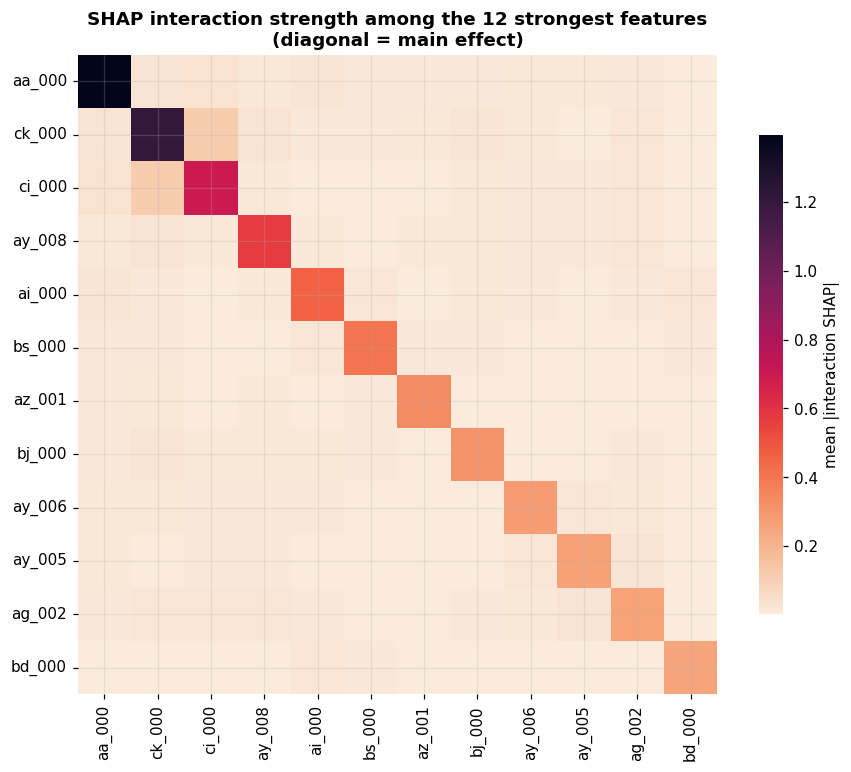

**Ten strongest pairwise interactions**

,Feature A,Feature B,mean |interaction|
0,ci_000,ck_000,0.1165
1,aa_000,ao_000,0.0657
2,aa_000,bt_000,0.0638
3,aa_000,bi_000,0.0600
4,bs_000,cb_000,0.0393
5,aa_000,ci_000,0.0387
6,bi_000,bj_000,0.0370
7,ck_000,ee_007,0.0355
8,ai_000,am_0,0.0331
9,aa_000,ck_000,0.0321


In [28]:
if is_xgb:
    pos_idx = np.where(y_s == 1)[0]; neg_idx = np.where(y_s == 0)[0]
    sel = np.r_[rng.choice(pos_idx, min(150, len(pos_idx)), replace=False),
                rng.choice(neg_idx, 500 - min(150, len(pos_idx)), replace=False)]
    inter = explainer.shap_interaction_values(X_s.iloc[sel])
    M = np.abs(inter).mean(0)
    feat = np.array(X_s.columns)
    top_main = np.argsort(-np.diag(M))[:12]
    Msub = pd.DataFrame(M[np.ix_(top_main, top_main)], index=feat[top_main], columns=feat[top_main])

    plt.figure(figsize=(8.5, 7))
    sns.heatmap(Msub, cmap="rocket_r", square=True, annot=False, cbar_kws={"label": "mean |interaction SHAP|", "shrink": .75})
    plt.title("SHAP interaction strength among the 12 strongest features\n(diagonal = main effect)"); plt.tight_layout(); plt.show()

    off = M.copy(); np.fill_diagonal(off, 0)
    iu = np.triu_indices_from(off, k=1)
    order = np.argsort(-off[iu])[:10]
    top_pairs = pd.DataFrame({"Feature A": feat[iu[0][order]], "Feature B": feat[iu[1][order]], "mean |interaction|": off[iu][order]})
    display(Markdown("**Ten strongest pairwise interactions**")); display(top_pairs)
else:
    print("Interaction values are only computed for XGBoost models.")

### 8.7 Explaining individual predictions (local SHAP)
Local explanations turn an alert into a *reason*. We examine the four cases that matter to an operator, at the cost-optimal threshold:

* **True positive** (highest confidence): a correctly flagged failure.
* **False negative** (closest miss): a failure the model let through, the expensive error.
* **False positive** (highest score): a false alarm.
* **True negative** (lowest score): a confident "healthy" call.

In a **waterfall plot** the bottom shows the base value `E[f(x)]`, each bar adds or subtracts a feature's contribution, and the top shows the final model output `f(x)` in log-odds.

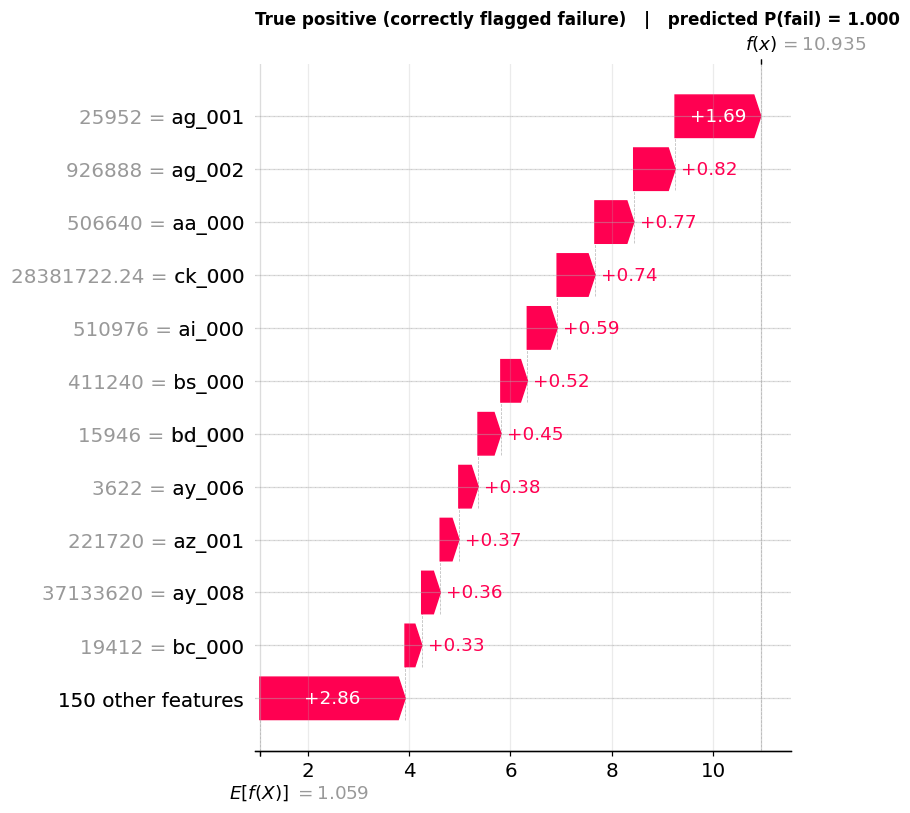

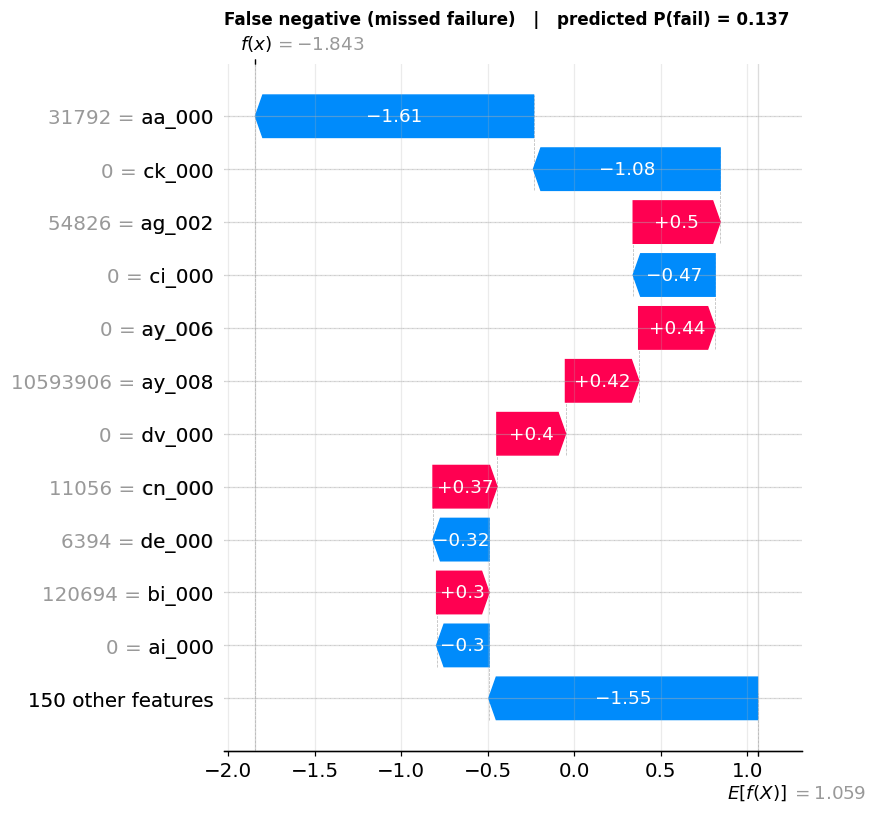

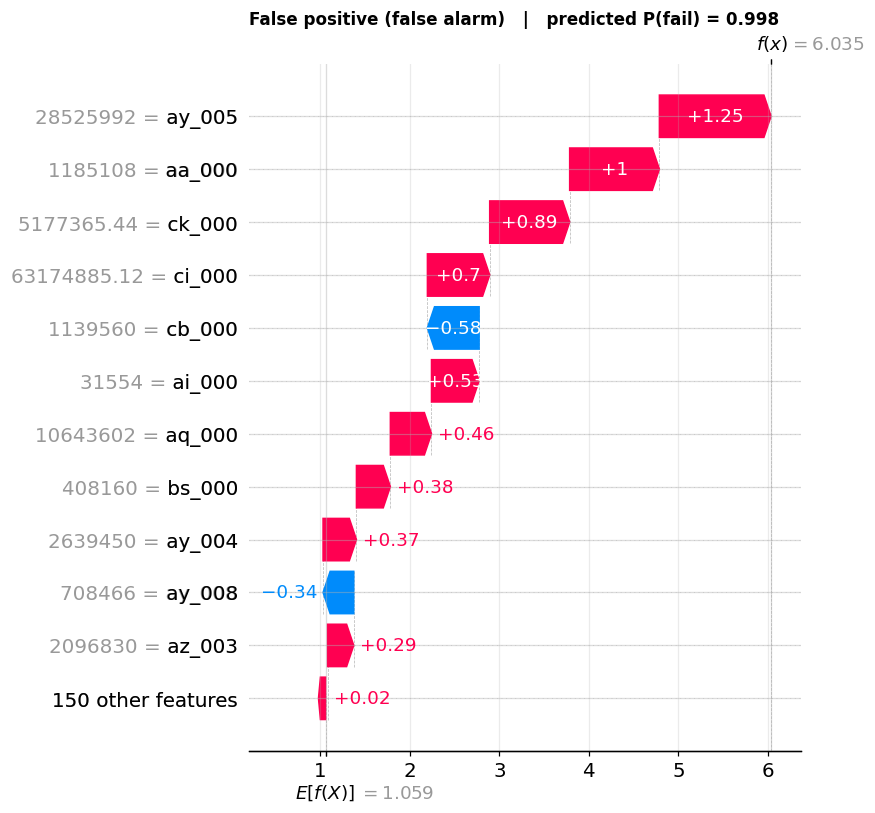

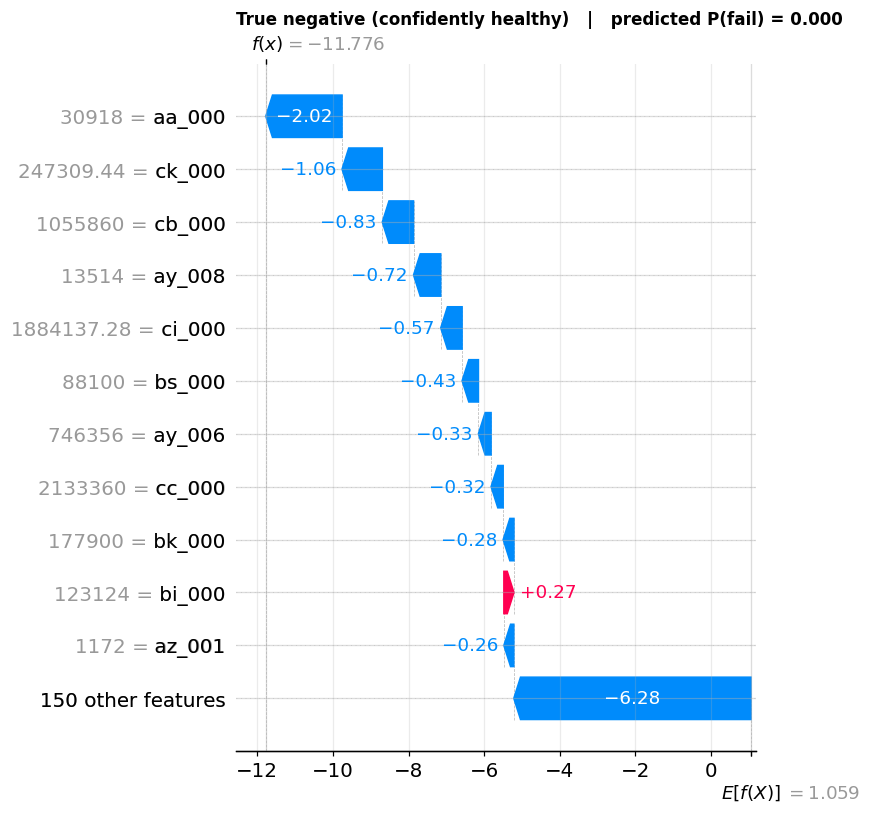

In [29]:
def pick(mask, highest=True):
    idx = np.where(mask)[0]
    if len(idx) == 0: return None
    return idx[np.argmax(p_s[idx])] if highest else idx[np.argmin(p_s[idx])]

cases = {
    "True positive (correctly flagged failure)":   pick((y_s == 1) & (pred_s == 1), True),
    "False negative (missed failure)":             pick((y_s == 1) & (pred_s == 0), True),
    "False positive (false alarm)":                pick((y_s == 0) & (pred_s == 1), True),
    "True negative (confidently healthy)":         pick((y_s == 0) & (pred_s == 0), False),
}
for title, i in cases.items():
    if i is None:
        print(f"[{title}] no such case at this threshold."); continue
    plt.figure(); shap.plots.waterfall(sv[i], max_display=12, show=False)
    plt.title(f"{title}   |   predicted P(fail) = {p_s[i]:.3f}", fontsize=11, loc="left"); plt.tight_layout(); plt.show()

**Force plot and decision plot.** The force plot shows the same information as a waterfall in a single horizontal bar (red pushes towards failure, blue towards healthy). The decision plot overlays many trucks: each line starts at the base value and moves as features are added, so you can see *where* failing and healthy trucks diverge.

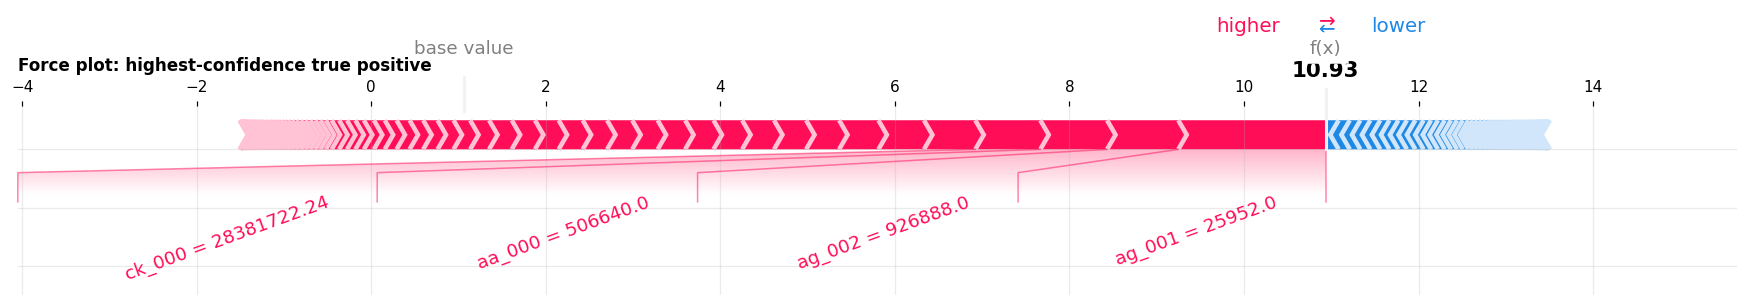

In [30]:
i_tp = cases["True positive (correctly flagged failure)"]
if i_tp is not None:
    try:
        shap.force_plot(base, sv.values[i_tp], X_s.iloc[i_tp], matplotlib=True, show=False, figsize=(16, 3.2), text_rotation=20)
        plt.title("Force plot: highest-confidence true positive", loc="left", fontsize=11); plt.tight_layout(); plt.show()
    except Exception as e:
        print("Force plot skipped:", e)

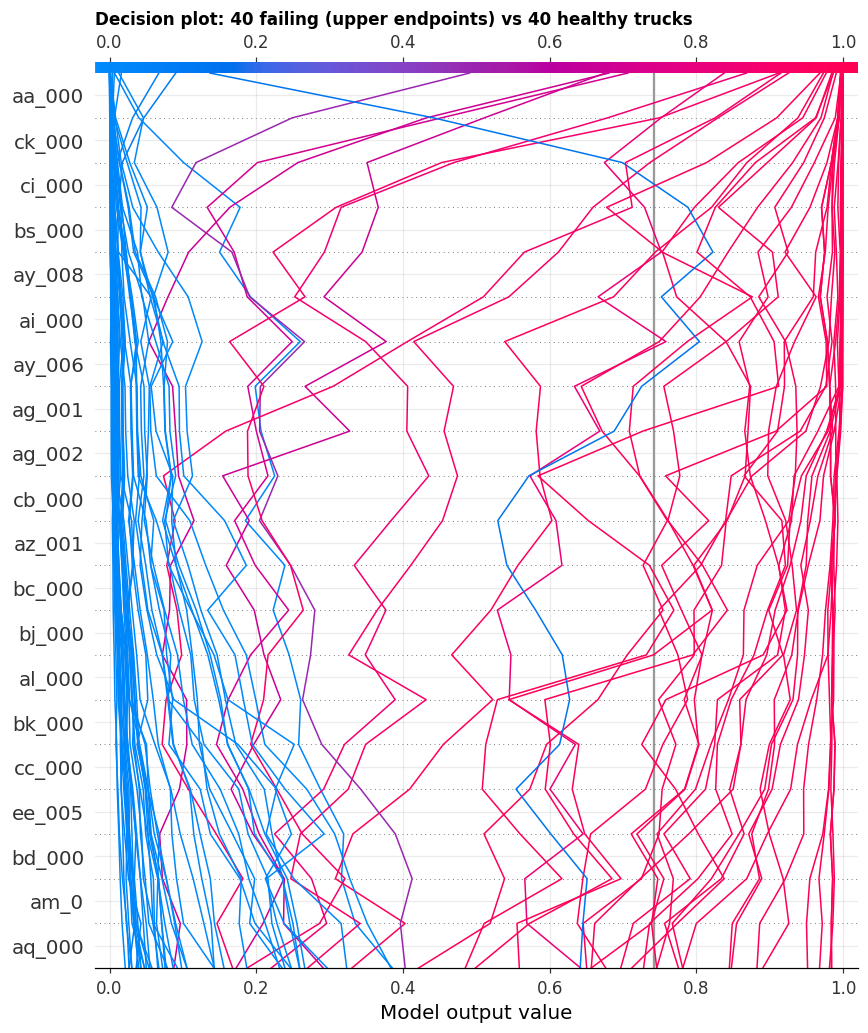

In [31]:
pos_idx = np.where(y_s == 1)[0]; neg_idx = np.where(y_s == 0)[0]
dsel = np.r_[rng.choice(pos_idx, min(40, len(pos_idx)), replace=False), rng.choice(neg_idx, 40, replace=False)]
link = "logit" if is_xgb else "identity"
shap.decision_plot(base, sv.values[dsel], X_s.iloc[dsel], link=link, feature_order="importance", show=False)
plt.title("Decision plot: 40 failing (upper endpoints) vs 40 healthy trucks", loc="left", fontsize=11); plt.tight_layout(); plt.show()

**Population view.** The heatmap stacks SHAP values for many trucks (columns), ordered by model output. Vertical bands show groups of trucks that fail for the *same reason*, which is the seed of a failure-mode taxonomy.

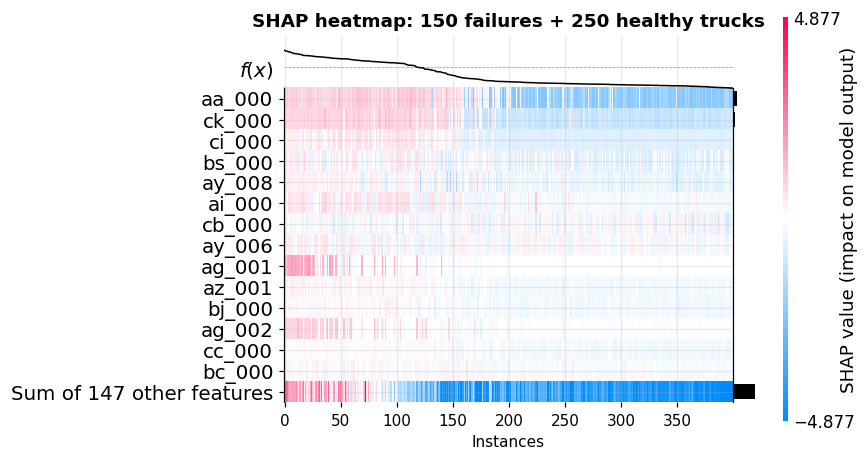

In [32]:
hm_idx = np.r_[rng.choice(pos_idx, min(150, len(pos_idx)), replace=False), rng.choice(neg_idx, 250, replace=False)]
sv_hm = sv[hm_idx]
plt.figure(); shap.plots.heatmap(sv_hm, max_display=15, instance_order=sv_hm.sum(1), show=False)
plt.title("SHAP heatmap: 150 failures + 250 healthy trucks"); plt.tight_layout(); plt.show()

### 8.8 Why did we miss those failures? (error-group SHAP profile)
Mean signed SHAP for each outcome group (TP, FN, FP, TN) across the top features. If **FN** columns look like **TN** columns, the missed failures simply do not exhibit the usual signature in the available sensors. If they look like **TP** but weaker, a lower threshold or more capacity would catch them.

Group sizes: {np.str_('FN'): np.int64(28), np.str_('FP'): np.int64(213), np.str_('TN'): np.int64(15412), np.str_('TP'): np.int64(347)}


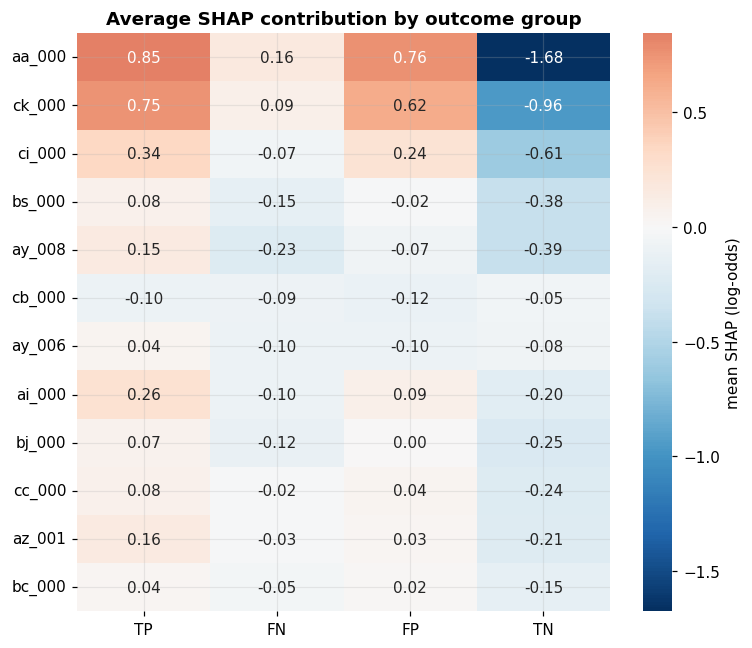

In [33]:
grp = np.select([(y_s == 1) & (pred_s == 1), (y_s == 1) & (pred_s == 0), (y_s == 0) & (pred_s == 1), (y_s == 0) & (pred_s == 0)], ["TP", "FN", "FP", "TN"], default="")
top12 = imp.index[:12]
prof = pd.DataFrame({g: pd.DataFrame(sv.values, columns=X_s.columns).loc[grp == g, top12].mean() for g in ["TP", "FN", "FP", "TN"] if (grp == g).any()})
print("Group sizes:", dict(zip(*np.unique(grp, return_counts=True))))
plt.figure(figsize=(7, 6))
sns.heatmap(prof, cmap="RdBu_r", center=0, annot=True, fmt=".2f", cbar_kws={"label": "mean SHAP (log-odds)"})
plt.title("Average SHAP contribution by outcome group"); plt.tight_layout(); plt.show()

### 8.9 Do different importance methods agree?
Impurity/gain importance is biased towards high-cardinality features, and permutation importance splits credit among correlated features differently from SHAP. Agreement across methods increases confidence; disagreement flags features to examine.

**Spearman rank correlation between importance methods**

,SHAP,Gain,Permutation
SHAP,1.00,0.42,0.63
Gain,0.42,1.00,0.39
Permutation,0.63,0.39,1.00


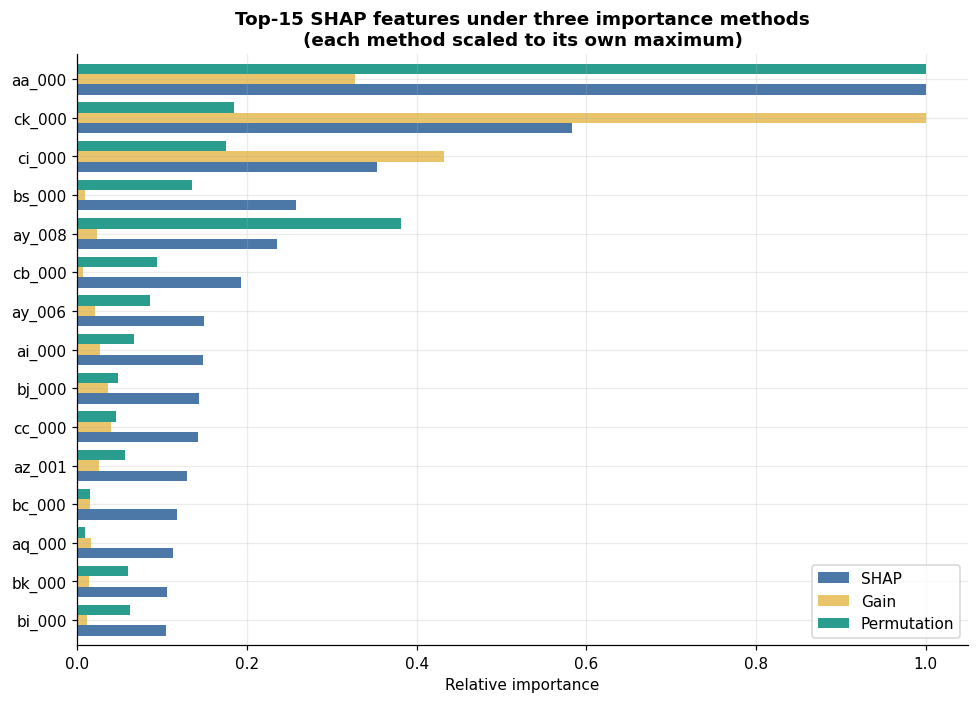

In [34]:
gain = pd.Series(get_booster(final_model).feature_importances_, index=X_te_p.columns) if hasattr(get_booster(final_model), "feature_importances_") else None
perm = permutation_importance(final_model, X_te_p, y_te, scoring="average_precision", n_repeats=3, random_state=RANDOM_STATE, n_jobs=-1)
perm_s = pd.Series(perm.importances_mean, index=X_te_p.columns)

comp = pd.DataFrame({"SHAP": imp, "Gain": gain, "Permutation": perm_s}).dropna()
rk = comp.rank(ascending=False)
rho = comp.corr(method="spearman")
display(Markdown("**Spearman rank correlation between importance methods**")); display(rho.style.format("{:.2f}").background_gradient(cmap="Blues", vmin=0, vmax=1))

top_union = comp["SHAP"].sort_values(ascending=False).head(15).index
plot_df = (comp.loc[top_union] / comp.loc[top_union].max())
plot_df.iloc[::-1].plot.barh(figsize=(9, 6.5), color=[COL["neg"], COL["gold"], COL["teal"]], width=.8)
plt.title("Top-15 SHAP features under three importance methods\n(each method scaled to its own maximum)"); plt.xlabel("Relative importance"); plt.tight_layout(); plt.show()

### 8.10 Robustness of the explanation
An explanation is only useful if it is stable. We recompute the ranking on five random 50% subsamples of the test set and measure how much the **top-15 feature set** overlaps with the full-sample top 15 (Jaccard index; 1.0 = identical).

In [35]:
ref = set(imp.index[:15]); jac = []
for _ in range(5):
    sub = rng.choice(len(X_s), len(X_s) // 2, replace=False)
    top_sub = set(pd.Series(np.abs(sv.values[sub]).mean(0), index=X_s.columns).sort_values(ascending=False).index[:15])
    jac.append(len(ref & top_sub) / len(ref | top_sub))
print("Jaccard overlap of top-15 features across subsamples:", np.round(jac, 2), f"| mean = {np.mean(jac):.2f}")

Jaccard overlap of top-15 features across subsamples: [1. 1. 1. 1. 1.] | mean = 1.00


### 8.11 SHAP-guided feature reduction
Can we keep the accuracy with far fewer sensors? A smaller model is cheaper to deploy and easier to monitor.

**Leakage guard:** features are ranked with SHAP computed on the **validation** set, never the test set. The reduced models are trained on the training split, thresholds tuned on validation, and evaluated once on the test set.

,PR-AUC,ROC-AUC,Recall,Test cost
Features,,,,
5,0.6544,0.9834,0.9573,"16,090"
10,0.7768,0.9889,0.9707,"13,500"
20,0.8498,0.9913,0.9733,"10,450"
40,0.9200,0.9934,0.9413,"14,140"
80,0.9257,0.9952,0.9680,"10,790"
161,0.9223,0.9947,0.9707,"10,450"


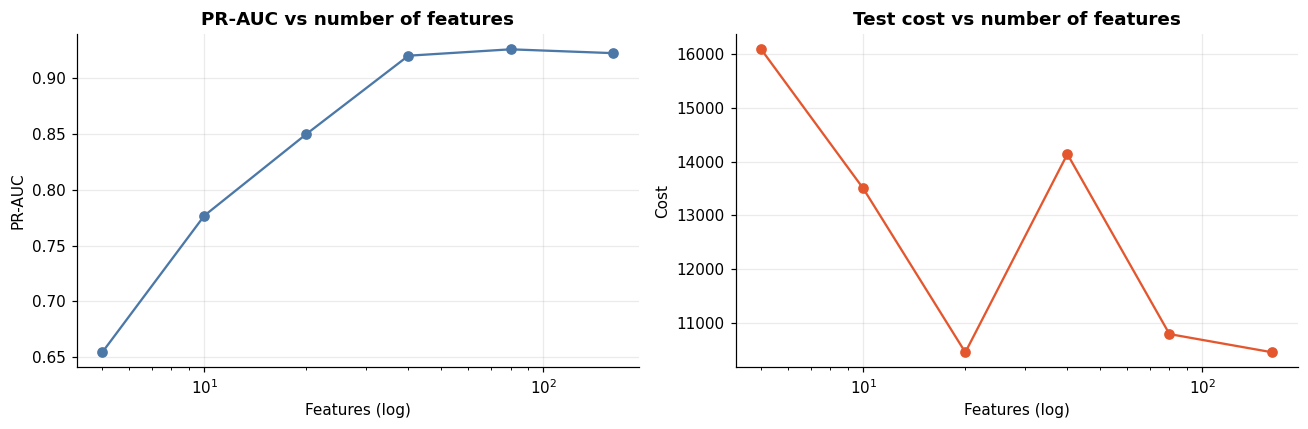

In [36]:
_, sv_val, X_val_s = compute_shap(final_model, X_val_p)
rank_val = pd.Series(np.abs(sv_val.values).mean(0), index=X_val_s.columns).sort_values(ascending=False).index.tolist()

ks = sorted({k for k in [5, 10, 20, 40, 80, len(rank_val)] if k <= len(rank_val)})
rows = []
for k in ks:
    cols = rank_val[:k]; m = clone(final_model).fit(X_tr_p[cols], y_tr)
    pv, pt = m.predict_proba(X_val_p[cols])[:, 1], m.predict_proba(X_te_p[cols])[:, 1]
    _, tc, _ = best_thresholds(y_val, pv)
    e = evaluate(f"top {k}", y_te, pt, tc); rows.append({"Features": k, "PR-AUC": e["PR-AUC"], "ROC-AUC": e["ROC-AUC"], "Recall": e["Recall"], "Test cost": e["Cost"]})
red = pd.DataFrame(rows).set_index("Features")
display(red.style.format({"PR-AUC": "{:.4f}", "ROC-AUC": "{:.4f}", "Recall": "{:.4f}", "Test cost": "{:,.0f}"}).highlight_min(subset=["Test cost"], color="#cfe8e4"))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(red.index, red["PR-AUC"], "o-", color=COL["neg"]); ax[0].set_xscale("log"); ax[0].set_title("PR-AUC vs number of features"); ax[0].set_xlabel("Features (log)"); ax[0].set_ylabel("PR-AUC")
ax[1].plot(red.index, red["Test cost"], "o-", color=COL["pos"]); ax[1].set_xscale("log"); ax[1].set_title("Test cost vs number of features"); ax[1].set_xlabel("Features (log)"); ax[1].set_ylabel("Cost")
plt.tight_layout(); plt.show()

## 9. Looking at risk scores and calibration
A maintenance planner wants to read a score as a *probability*. Class weighting and SMOTE both distort probabilities, so we check calibration and report the Brier score (lower is better). If the curve lies below the diagonal, the model over-predicts failure risk. That is acceptable for ranking and thresholding, but scores should be recalibrated (Platt scaling or isotonic regression) before being shown as percentages.

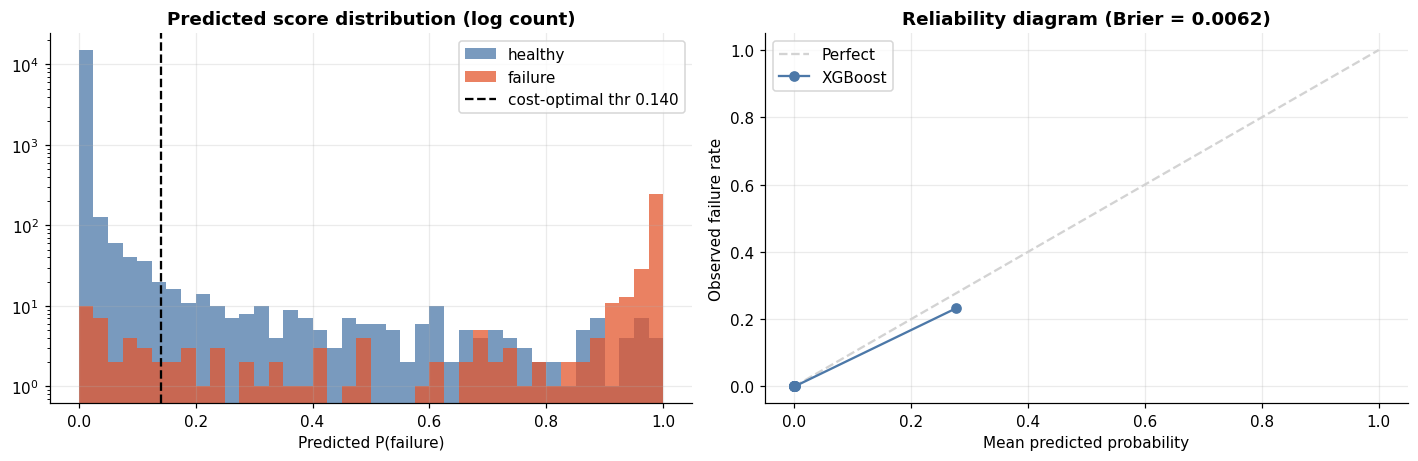

In [37]:
p = test_proba[final_name]
fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
bins = np.linspace(0, 1, 41)
ax[0].hist(p[y_te == 0], bins=bins, alpha=.75, color=COL["neg"], label="healthy", log=True)
ax[0].hist(p[y_te == 1], bins=bins, alpha=.75, color=COL["pos"], label="failure", log=True)
ax[0].axvline(thr_cost, color="black", ls="--", label=f"cost-optimal thr {thr_cost:.3f}")
ax[0].set_title("Predicted score distribution (log count)"); ax[0].set_xlabel("Predicted P(failure)"); ax[0].legend()
frac, mean_p = calibration_curve(y_te, p, n_bins=10, strategy="quantile")
ax[1].plot([0, 1], [0, 1], "--", color="lightgrey", label="Perfect"); ax[1].plot(mean_p, frac, "o-", color=COL["neg"], label=f"{final_name}")
ax[1].set_title(f"Reliability diagram (Brier = {brier_score_loss(y_te, p):.4f})"); ax[1].set_xlabel("Mean predicted probability"); ax[1].set_ylabel("Observed failure rate"); ax[1].legend()
plt.tight_layout(); plt.show()

## 10. Saving the work and wrapping up
### 10.1 Save the deliverables
Everything needed to reproduce the scoring pipeline and feed a dashboard (for example the Streamlit concept) is written to the output folder.

In [38]:
joblib.dump({"model": final_model, "imputer": imputer, "features": keep}, OUTPUT_DIR / "aps_final_model.joblib")
json.dump({"model": final_name, "threshold_cost_optimal": float(thr_cost), "threshold_f1_optimal": float(thr_f1),
           "cost_fp": COST_FP, "cost_fn": COST_FN, "random_state": RANDOM_STATE}, open(OUTPUT_DIR / "aps_config.json", "w"), indent=2)
test_all.to_csv(OUTPUT_DIR / "aps_test_metrics_all_models.csv"); ops.to_csv(OUTPUT_DIR / "aps_test_operating_points.csv")
imp.rename("mean_abs_shap").to_csv(OUTPUT_DIR / "aps_shap_global_importance.csv")
fam_n.rename("pct_importance").to_csv(OUTPUT_DIR / "aps_shap_family_importance.csv")
print("Saved:", *sorted(p.name for p in OUTPUT_DIR.glob("aps_*")), sep="\n  ")

Saved:
  aps_config.json
  aps_final_model.joblib
  aps_shap_family_importance.csv
  aps_shap_global_importance.csv
  aps_test_metrics_all_models.csv
  aps_test_operating_points.csv


### 10.2 Results summary (auto-generated from this run)

In [39]:
co = ops.loc["Cost-optimal"]
display(Markdown(f'''
* **Selected model:** {final_name} (lowest validation cost among tree ensembles).
* **Operating threshold:** {thr_cost:.3f} (cost-optimal), {thr_f1:.3f} (F1-optimal), tuned on validation only.
* **Hold-out test cost:** **{co["Cost"]:,.0f}** (95% CI {lo:,.0f} to {hi:,.0f}) against {policies.iloc[0]:,.0f} for "never inspect" and {policies.iloc[1]:,.0f} for "inspect everything".
* **Detection:** recall {co["Recall"]:.1%}, precision {co["Precision"]:.1%}, {int(co["FN"])} missed failures and {int(co["FP"]):,} false alarms.
* **Explainability:** the top {n80} features carry 80% of total SHAP importance; the leading sensor family is `{fam_n.index[0]}` ({fam_n.iloc[0]:.1f}% of importance); explanation stability (Jaccard) = {np.mean(jac):.2f}.
'''))


* **Selected model:** XGBoost (lowest validation cost among tree ensembles).
* **Operating threshold:** 0.140 (cost-optimal), 0.820 (F1-optimal), tuned on validation only.
* **Hold-out test cost:** **16,130** (95% CI 10,924 to 21,362) against 187,500 for "never inspect" and 156,250 for "inspect everything".
* **Detection:** recall 92.5%, precision 62.0%, 28 missed failures and 213 false alarms.
* **Explainability:** the top 57 features carry 80% of total SHAP importance; the leading sensor family is `aa` (12.6% of importance); explanation stability (Jaccard) = 1.00.
